# main project-Copy1

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# import tensorflow as tf


In [2]:
# # Do we have access to a GPU?
# device_list = tf.config.list_physical_devices()
# if "GPU" in [device.device_type for device in device_list]:
#   print(f"[INFO] TensorFlow has GPU available to use. Woohoo!! Computing will be sped up!")
#   print(f"[INFO] Accessible devices:\n{device_list}")
# else:
#   print(f"[INFO] TensorFlow does not have GPU available to use. Models may take a while to train.")
#   print(f"[INFO] Accessible devices:\n{device_list}")

In [3]:
df=pd.read_csv("NICA.csv")

In [4]:
df.head()

,Date,Open,High,Low,Close,per_change,Qty,Turnover,EPS,PE
0,2/20/2025,384.5,384.5,373.6,374.5,-0.66,42089,15847811.6,2.04,183.578431
1,2/18/2025,389.0,389.6,375.0,377.0,-1.31,74518,28374584.9,2.04,184.803922
2,2/17/2025,371.0,386.9,370.7,382.0,3.05,108899,41212054.5,2.04,187.254902
3,2/16/2025,367.0,370.9,365.0,370.7,2.12,70533,26014490.4,2.04,181.715686
4,2/13/2025,360.0,366.0,360.0,363.0,-0.03,47627,17318839.0,2.04,177.941177


In [5]:
df['Date'] = pd.to_datetime(df['Date']) 

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1920 entries, 0 to 1919
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        1920 non-null   datetime64[ns]
 1   Open        1920 non-null   float64       
 2   High        1920 non-null   float64       
 3   Low         1920 non-null   float64       
 4   Close       1920 non-null   float64       
 5   per_change  1920 non-null   float64       
 6   Qty         1920 non-null   int64         
 7   Turnover    1920 non-null   float64       
 8   EPS         1920 non-null   float64       
 9   PE          1920 non-null   float64       
dtypes: datetime64[ns](1), float64(8), int64(1)
memory usage: 150.1 KB


In [7]:
# !conda install -c conda-forge ta-lib -y
#ta lib is technical technical analysis

In [8]:
import talib as ta

In [9]:
#calculatins ema using talib for 5,50 and 200 days as 5 days for short term(also 5 days nepse opening in a week),50 days for middle term and 200 days for long term (generally there are only 250 opening days in year of nepse)

In [10]:
df['EMA5'] = ta.EMA(df['Close'], timeperiod=5)
df['EMA50'] = ta.EMA(df['Close'], timeperiod=50)
df['EMA200'] = ta.EMA(df['Close'], timeperiod=200)

In [11]:
df.head()

,Date,Open,High,Low,Close,per_change,Qty,Turnover,EPS,PE,EMA5,EMA50,EMA200
0,2025-02-20,384.5,384.5,373.6,374.5,-0.66,42089,15847811.6,2.04,183.578431,NaN,NaN,NaN
1,2025-02-18,389.0,389.6,375.0,377.0,-1.31,74518,28374584.9,2.04,184.803922,NaN,NaN,NaN
2,2025-02-17,371.0,386.9,370.7,382.0,3.05,108899,41212054.5,2.04,187.254902,NaN,NaN,NaN
3,2025-02-16,367.0,370.9,365.0,370.7,2.12,70533,26014490.4,2.04,181.715686,NaN,NaN,NaN
4,2025-02-13,360.0,366.0,360.0,363.0,-0.03,47627,17318839.0,2.04,177.941177,373.44,NaN,NaN


In [12]:
df["EMA5"].isna().sum()

np.int64(4)

In [13]:
# df

In [14]:
df['RSI9'] = ta.RSI(df['Close'], timeperiod=9)
df['RSI14'] = ta.RSI(df['Close'], timeperiod=14)
df['RSI25'] = ta.RSI(df['Close'], timeperiod=25)


In [15]:
df.head()

,Date,Open,High,Low,Close,per_change,Qty,Turnover,EPS,PE,EMA5,EMA50,EMA200,RSI9,RSI14,RSI25
0,2025-02-20,384.5,384.5,373.6,374.5,-0.66,42089,15847811.6,2.04,183.578431,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-02-18,389.0,389.6,375.0,377.0,-1.31,74518,28374584.9,2.04,184.803922,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-02-17,371.0,386.9,370.7,382.0,3.05,108899,41212054.5,2.04,187.254902,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-02-16,367.0,370.9,365.0,370.7,2.12,70533,26014490.4,2.04,181.715686,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-02-13,360.0,366.0,360.0,363.0,-0.03,47627,17318839.0,2.04,177.941177,373.44,NaN,NaN,NaN,NaN,NaN


In [16]:
df["RSI25"].isna().sum()

np.int64(25)

In [17]:
df['MACD'], df['MACDSignal'], df['MACDHist'] = ta.MACD(df['Close'], 
                                                             fastperiod=12, 
                                                             slowperiod=26, 
                                                             signalperiod=9)

In [18]:
df.head()

,Date,Open,High,Low,Close,per_change,Qty,Turnover,EPS,PE,EMA5,EMA50,EMA200,RSI9,RSI14,RSI25,MACD,MACDSignal,MACDHist
0,2025-02-20,384.5,384.5,373.6,374.5,-0.66,42089,15847811.6,2.04,183.578431,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-02-18,389.0,389.6,375.0,377.0,-1.31,74518,28374584.9,2.04,184.803922,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-02-17,371.0,386.9,370.7,382.0,3.05,108899,41212054.5,2.04,187.254902,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-02-16,367.0,370.9,365.0,370.7,2.12,70533,26014490.4,2.04,181.715686,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-02-13,360.0,366.0,360.0,363.0,-0.03,47627,17318839.0,2.04,177.941177,373.44,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
# some rows of macd calculations are null because of ema calculations:

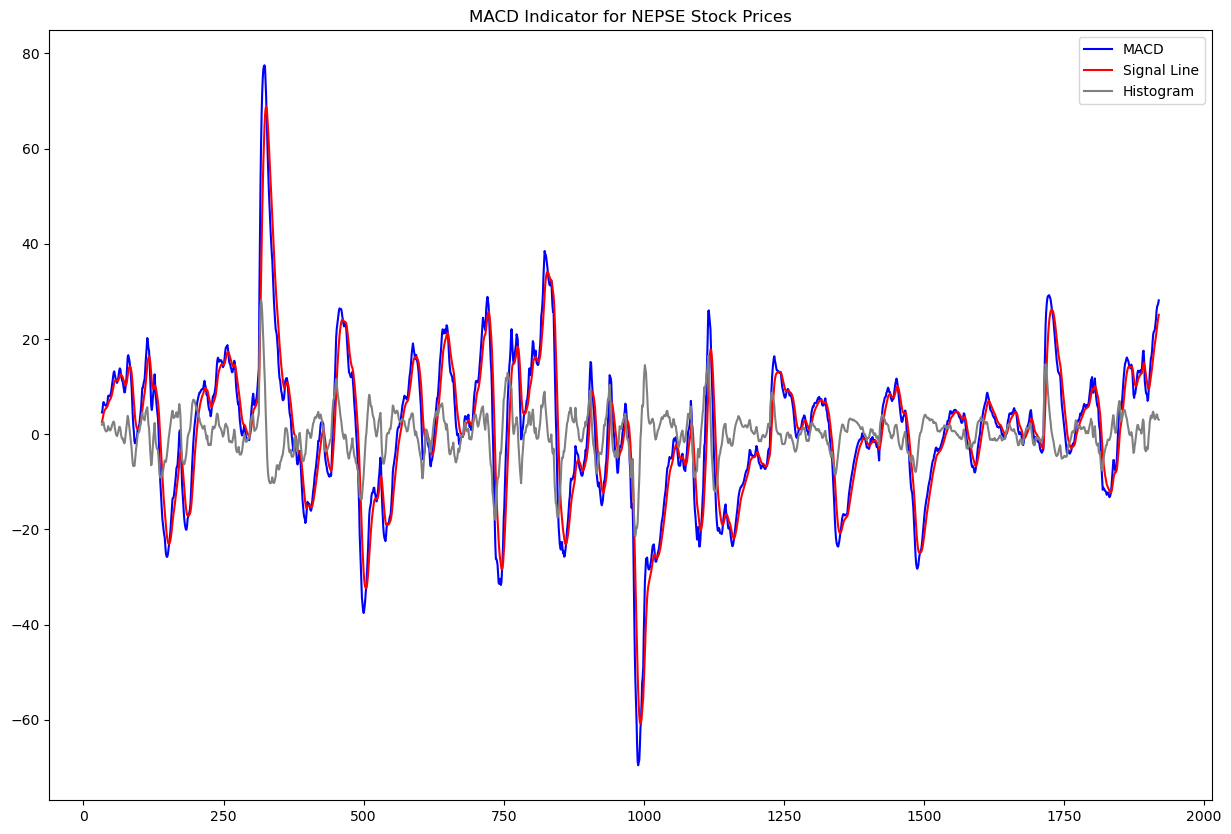

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))
plt.plot(df['MACD'], label="MACD", color='blue')
plt.plot(df['MACDSignal'], label="Signal Line", color='red')
plt.plot(df.index, df['MACDHist'], label="Histogram", color='gray')
plt.legend()
plt.title("MACD Indicator for NEPSE Stock Prices")
plt.show()


In [21]:
#calculationg bollingerband

In [22]:
df['BollingerUpper'], df['BollingerMiddle'], df['BollingerLower'] = ta.BBANDS(df['Close'], timeperiod=20, nbdevup=2, nbdevdn=2, matype=0)


In [23]:
df.head()

,Date,Open,High,Low,Close,per_change,Qty,Turnover,EPS,PE,...,EMA200,RSI9,RSI14,RSI25,MACD,MACDSignal,MACDHist,BollingerUpper,BollingerMiddle,BollingerLower
0,2025-02-20,384.5,384.5,373.6,374.5,-0.66,42089,15847811.6,2.04,183.578431,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-02-18,389.0,389.6,375.0,377.0,-1.31,74518,28374584.9,2.04,184.803922,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-02-17,371.0,386.9,370.7,382.0,3.05,108899,41212054.5,2.04,187.254902,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-02-16,367.0,370.9,365.0,370.7,2.12,70533,26014490.4,2.04,181.715686,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-02-13,360.0,366.0,360.0,363.0,-0.03,47627,17318839.0,2.04,177.941177,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:
df["BollingerUpper"].isna().sum()

np.int64(19)

In [25]:
# Plotting the Closing Price and Bollinger Bands


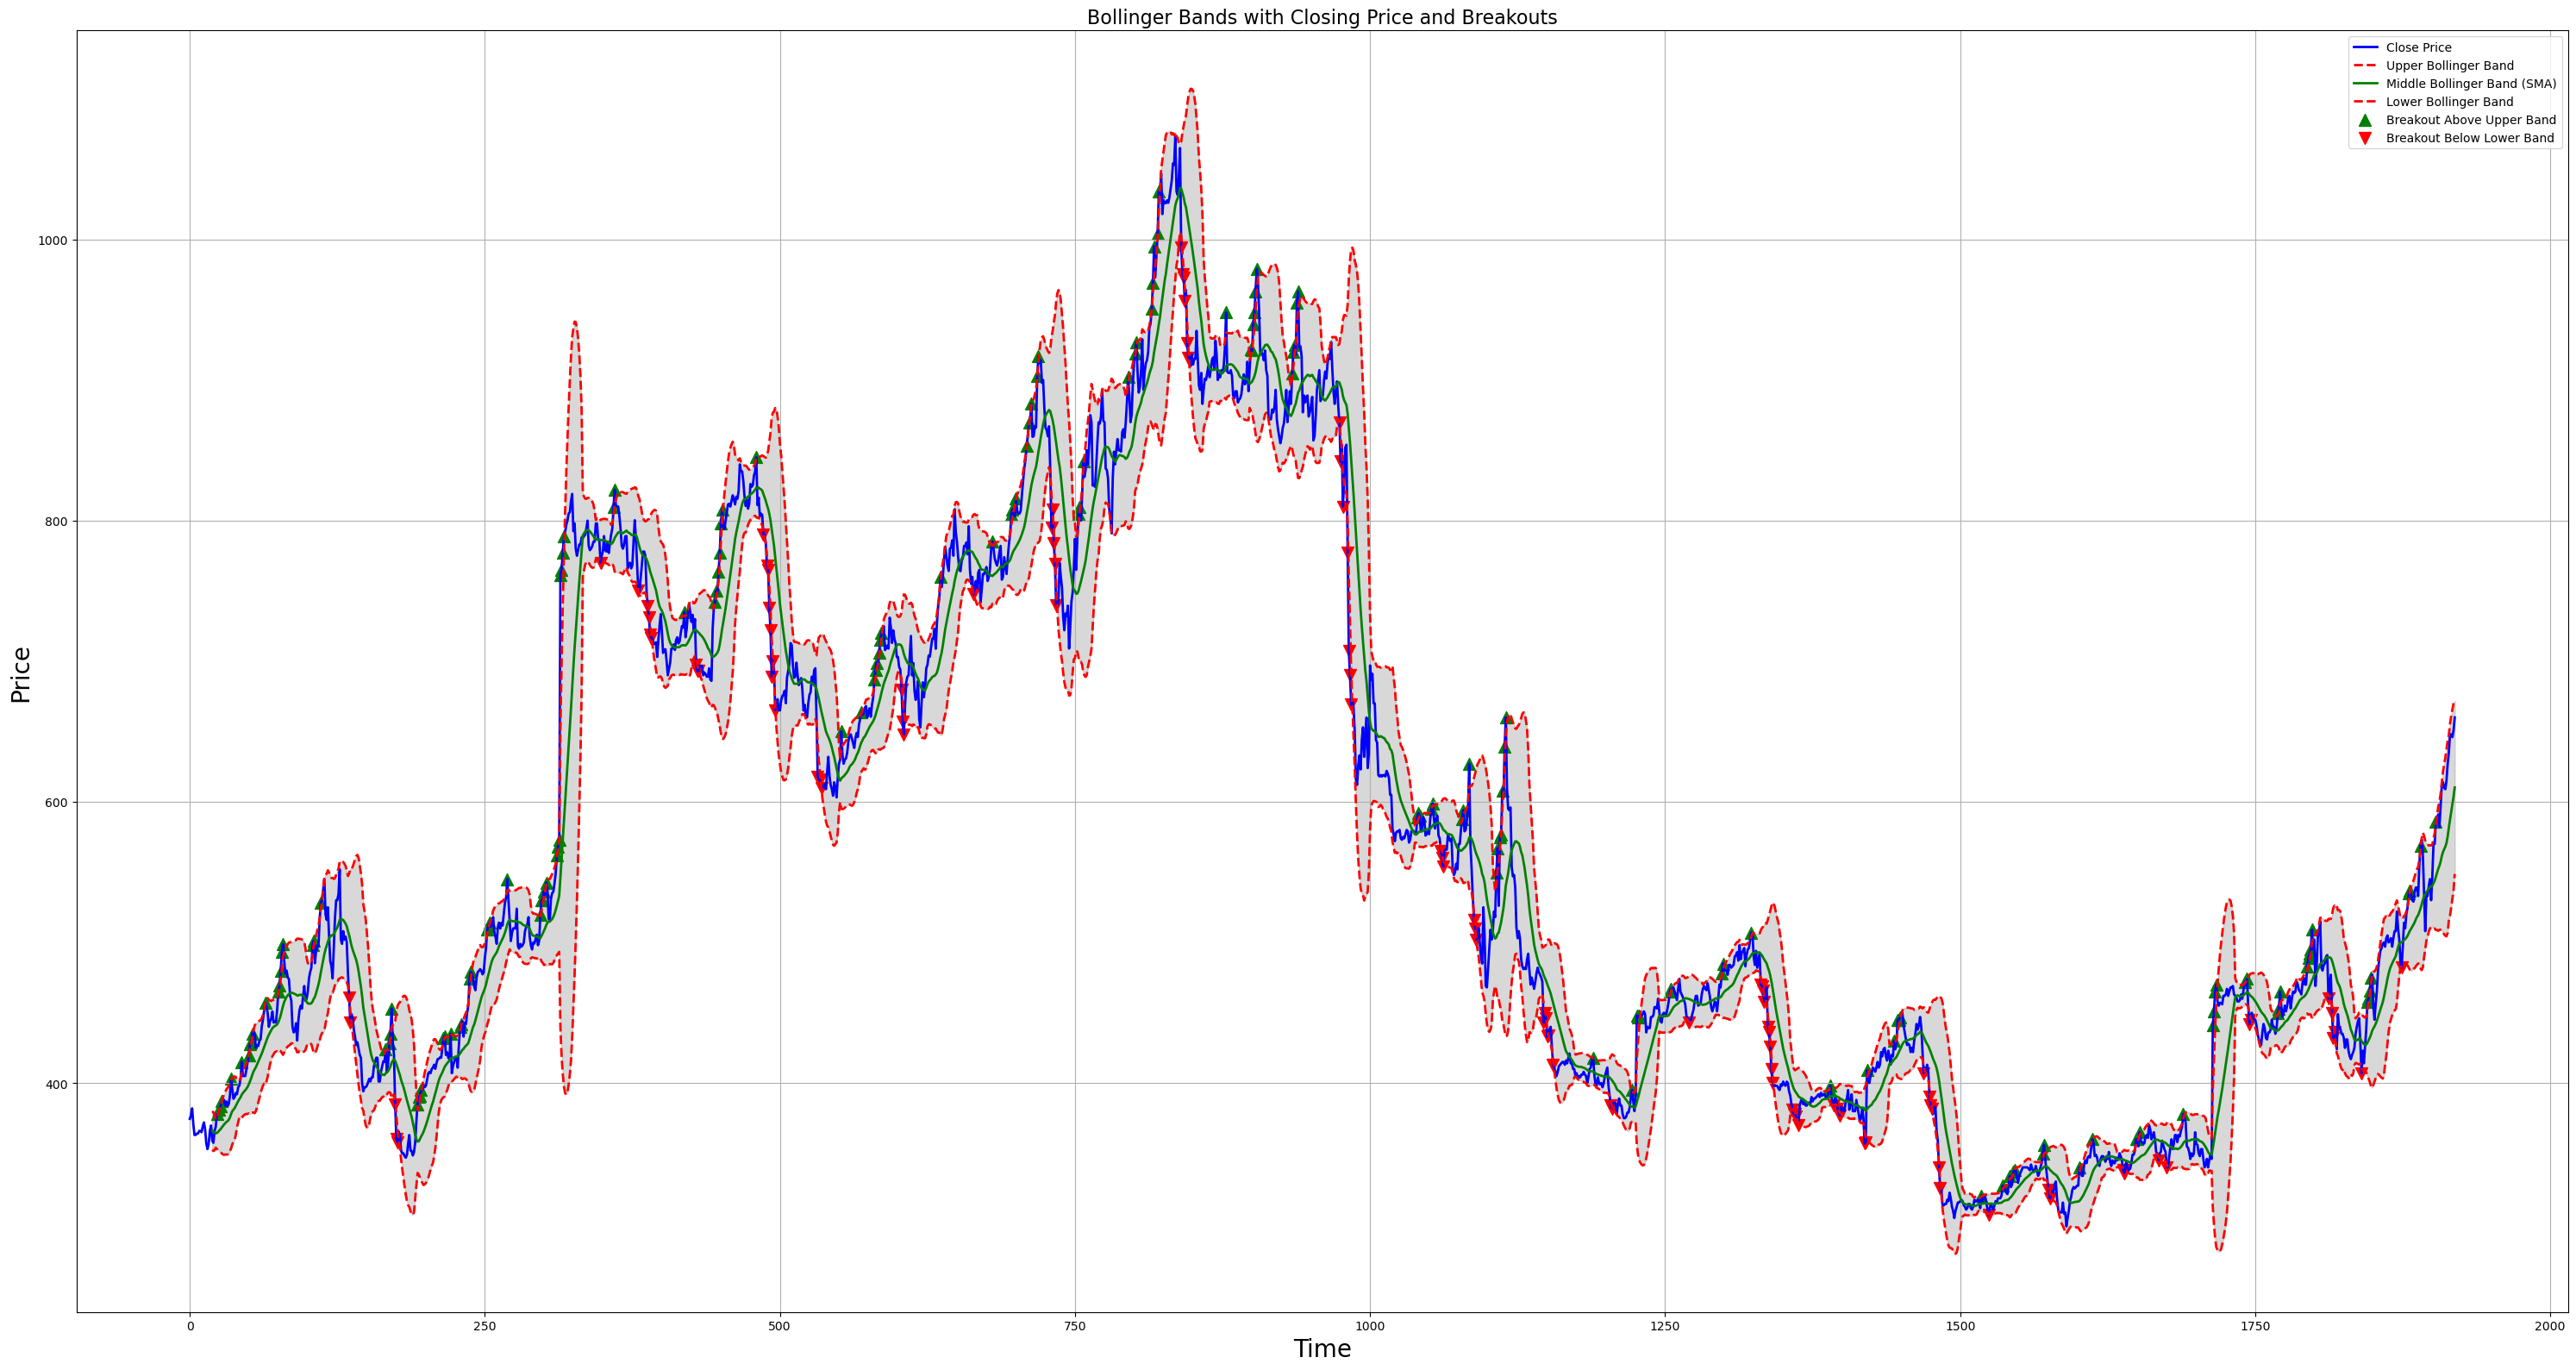

In [26]:
# Plotting the Closing Price and Bollinger Bands
plt.figure(figsize=(30,16))

# Plotting the Close Price
plt.plot(df['Close'], label='Close Price', color='blue', lw=2)

# Plotting the Bollinger Bands
plt.plot(df['BollingerUpper'], label='Upper Bollinger Band', color='red', linestyle='--', lw=2)
plt.plot(df['BollingerMiddle'], label='Middle Bollinger Band (SMA)', color='green', lw=2)
plt.plot(df['BollingerLower'], label='Lower Bollinger Band', color='red', linestyle='--', lw=2)

# Filling the area between Upper and Lower Bands for volatility
plt.fill_between(df.index, df['BollingerLower'], df['BollingerUpper'], color='gray', alpha=0.3)

# Highlight when price crosses above the Upper Band or below the Lower Band
plt.scatter(df.index[df['Close'] > df['BollingerUpper']], 
            df['Close'][df['Close'] > df['BollingerUpper']], 
            color='green', marker='^', label='Breakout Above Upper Band', s=100)

plt.scatter(df.index[df['Close'] < df['BollingerLower']], 
            df['Close'][df['Close'] < df['BollingerLower']], 
            color='red', marker='v', label='Breakout Below Lower Band', s=100)

# Title, labels, and legend
plt.title('Bollinger Bands with Closing Price and Breakouts', fontsize=16)
plt.xlabel('Time', fontsize=20)
plt.ylabel('Price', fontsize=20)
plt.legend(loc='best')

# Add gridlines for better clarity
plt.grid(True)

# Show the plot
plt.tight_layout()
plt.show()

In [27]:
#calculatid ATR and supertrend

In [28]:
# Calculate the ATR (Average True Range) for a 14-period window
df['ATR'] = ta.ATR(df['High'], df['Low'], df['Close'], timeperiod=10)

# Supertrend calculation parameters
multiplier = 3
df['UpperBand'] = (df['High'] + df['Low']) / 2 + (multiplier * df['ATR'])
df['LowerBand'] = (df['High'] + df['Low']) / 2 - (multiplier * df['ATR'])

# Initialize Supertrend column
df['Supertrend'] = 0.0

# Set initial values for Supertrend
upper_band = df['UpperBand'].values
lower_band = df['LowerBand'].values
close = df['Close'].values
supertrend = df['Supertrend'].values

for i in range(1, len(df)):
    if close[i] > upper_band[i-1]:
        supertrend[i] = lower_band[i]
    elif close[i] < lower_band[i-1]:
        supertrend[i] = upper_band[i]
    else:
        supertrend[i] = supertrend[i-1]

df['Supertrend'] = supertrend


In [29]:
df.head()

,Date,Open,High,Low,Close,per_change,Qty,Turnover,EPS,PE,...,MACD,MACDSignal,MACDHist,BollingerUpper,BollingerMiddle,BollingerLower,ATR,UpperBand,LowerBand,Supertrend
0,2025-02-20,384.5,384.5,373.6,374.5,-0.66,42089,15847811.6,2.04,183.578431,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
1,2025-02-18,389.0,389.6,375.0,377.0,-1.31,74518,28374584.9,2.04,184.803922,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2,2025-02-17,371.0,386.9,370.7,382.0,3.05,108899,41212054.5,2.04,187.254902,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
3,2025-02-16,367.0,370.9,365.0,370.7,2.12,70533,26014490.4,2.04,181.715686,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
4,2025-02-13,360.0,366.0,360.0,363.0,-0.03,47627,17318839.0,2.04,177.941177,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0


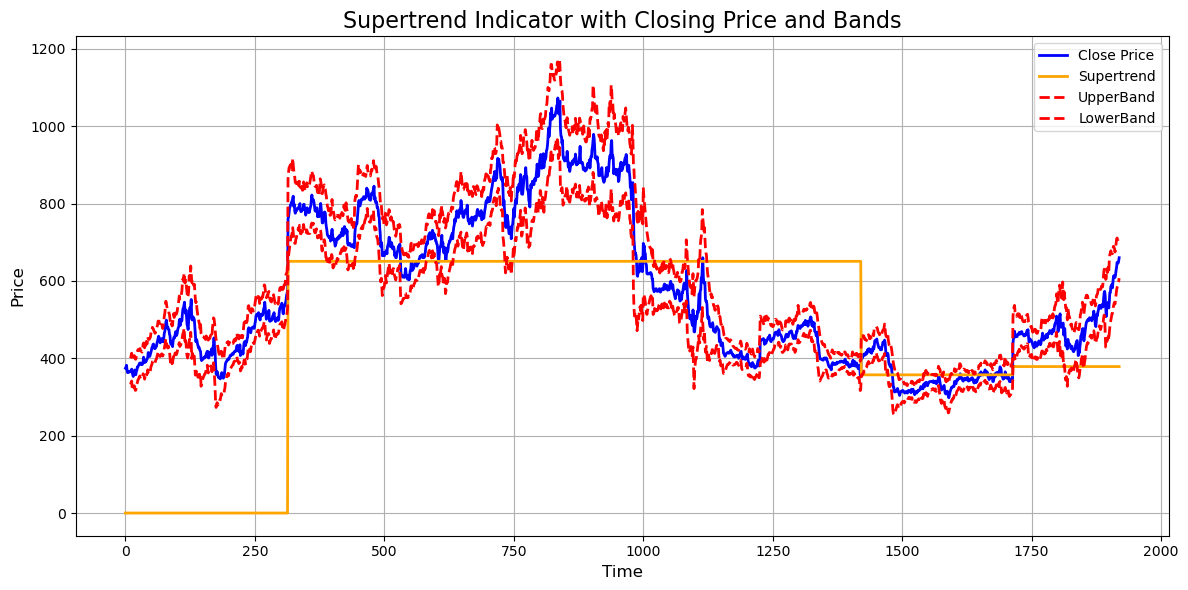

In [30]:
# Plotting the Supertrend with Closing Price
plt.figure(figsize=(12,6))

# Plotting the Close Price
plt.plot(df['Close'], label='Close Price', color='blue', lw=2)

# Plotting the Supertrend
plt.plot(df['Supertrend'], label='Supertrend', color='orange', lw=2)

# Plotting the Upper and Lower Bands for reference
plt.plot(df['UpperBand'], label='UpperBand', color='red', linestyle='--', lw=2)
plt.plot(df['LowerBand'], label='LowerBand', color='red', linestyle='--', lw=2)

# Title, labels, and legend
plt.title('Supertrend Indicator with Closing Price and Bands', fontsize=16)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.legend(loc='best')

# Add gridlines for better clarity
plt.grid(True)

# Show the plot
plt.tight_layout()
plt.show()

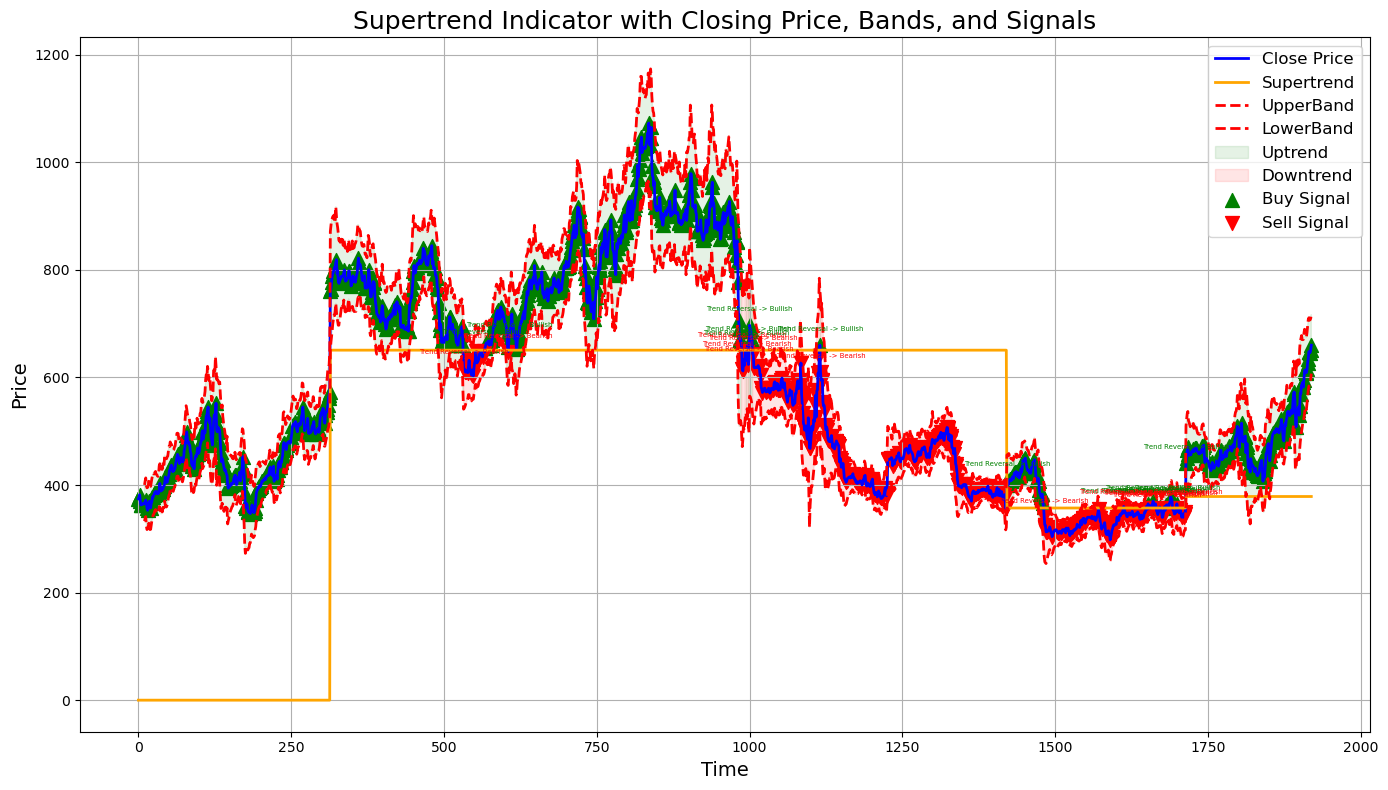

In [31]:


# Plotting the Supertrend with Closing Price
plt.figure(figsize=(14, 8))

# Plotting the Close Price
plt.plot(df['Close'], label='Close Price', color='blue', lw=2)

# Plotting the Supertrend
plt.plot(df['Supertrend'], label='Supertrend', color='orange', lw=2)

# Plotting the Upper and Lower Bands for reference
plt.plot(df['UpperBand'], label='UpperBand', color='red', linestyle='--', lw=2)
plt.plot(df['LowerBand'], label='LowerBand', color='red', linestyle='--', lw=2)

# Shading the areas for Uptrend and Downtrend
plt.fill_between(df.index, df['LowerBand'], df['UpperBand'], where=(df['Close'] > df['Supertrend']), color='green', alpha=0.1, label='Uptrend')
plt.fill_between(df.index, df['LowerBand'], df['UpperBand'], where=(df['Close'] < df['Supertrend']), color='red', alpha=0.1, label='Downtrend')

# Highlight Buy and Sell signals (where price crosses the Supertrend)
buy_signals = df[df['Close'] > df['Supertrend']].index
sell_signals = df[df['Close'] < df['Supertrend']].index

plt.scatter(buy_signals, df['Close'][buy_signals], color='green', marker='^', label='Buy Signal', s=100)
plt.scatter(sell_signals, df['Close'][sell_signals], color='red', marker='v', label='Sell Signal', s=100)

# Title, labels, and legend
plt.title('Supertrend Indicator with Closing Price, Bands, and Signals', fontsize=18)
plt.xlabel('Time', fontsize=14)
plt.ylabel('Price', fontsize=14)
plt.legend(loc='best', fontsize=12)

# Add gridlines for better clarity
plt.grid(True)

# Annotate for clarity (if needed)
for i in range(1, len(df)):
    if df['Close'][i] > df['Supertrend'][i] and df['Close'][i-1] < df['Supertrend'][i-1]:
        plt.annotate('Trend Reversal -> Bullish', (df.index[i], df['Close'][i]), textcoords="offset points", xytext=(0,10), ha='center', fontsize=5, color='green')
    elif df['Close'][i] < df['Supertrend'][i] and df['Close'][i-1] > df['Supertrend'][i-1]:
        plt.annotate('Trend Reversal -> Bearish', (df.index[i], df['Close'][i]), textcoords="offset points", xytext=(0,10), ha='center', fontsize=5, color='red')

# Show the plot
plt.tight_layout()
plt.show()


In [32]:
df.head()

,Date,Open,High,Low,Close,per_change,Qty,Turnover,EPS,PE,...,MACD,MACDSignal,MACDHist,BollingerUpper,BollingerMiddle,BollingerLower,ATR,UpperBand,LowerBand,Supertrend
0,2025-02-20,384.5,384.5,373.6,374.5,-0.66,42089,15847811.6,2.04,183.578431,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
1,2025-02-18,389.0,389.6,375.0,377.0,-1.31,74518,28374584.9,2.04,184.803922,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2,2025-02-17,371.0,386.9,370.7,382.0,3.05,108899,41212054.5,2.04,187.254902,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
3,2025-02-16,367.0,370.9,365.0,370.7,2.12,70533,26014490.4,2.04,181.715686,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
4,2025-02-13,360.0,366.0,360.0,363.0,-0.03,47627,17318839.0,2.04,177.941177,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0


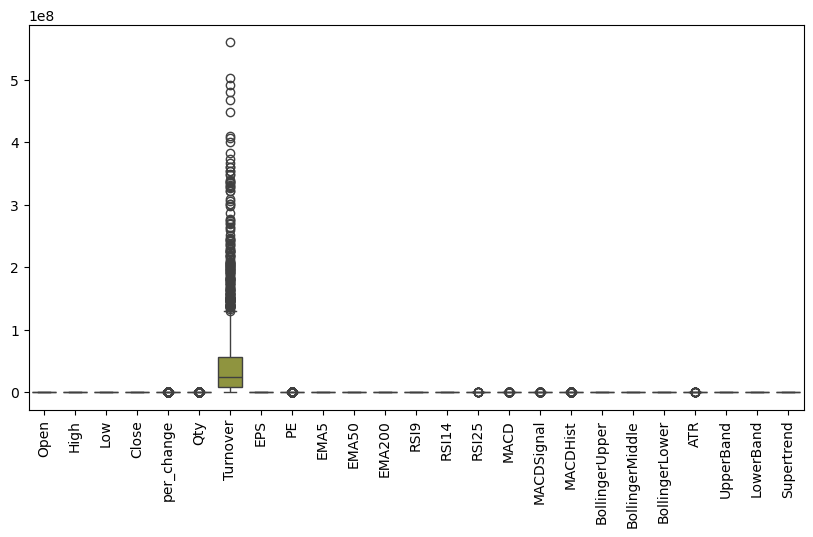

In [33]:
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.boxplot(data=df)
plt.xticks(rotation=90)  # Rotate x-axis labels for readability
plt.show()


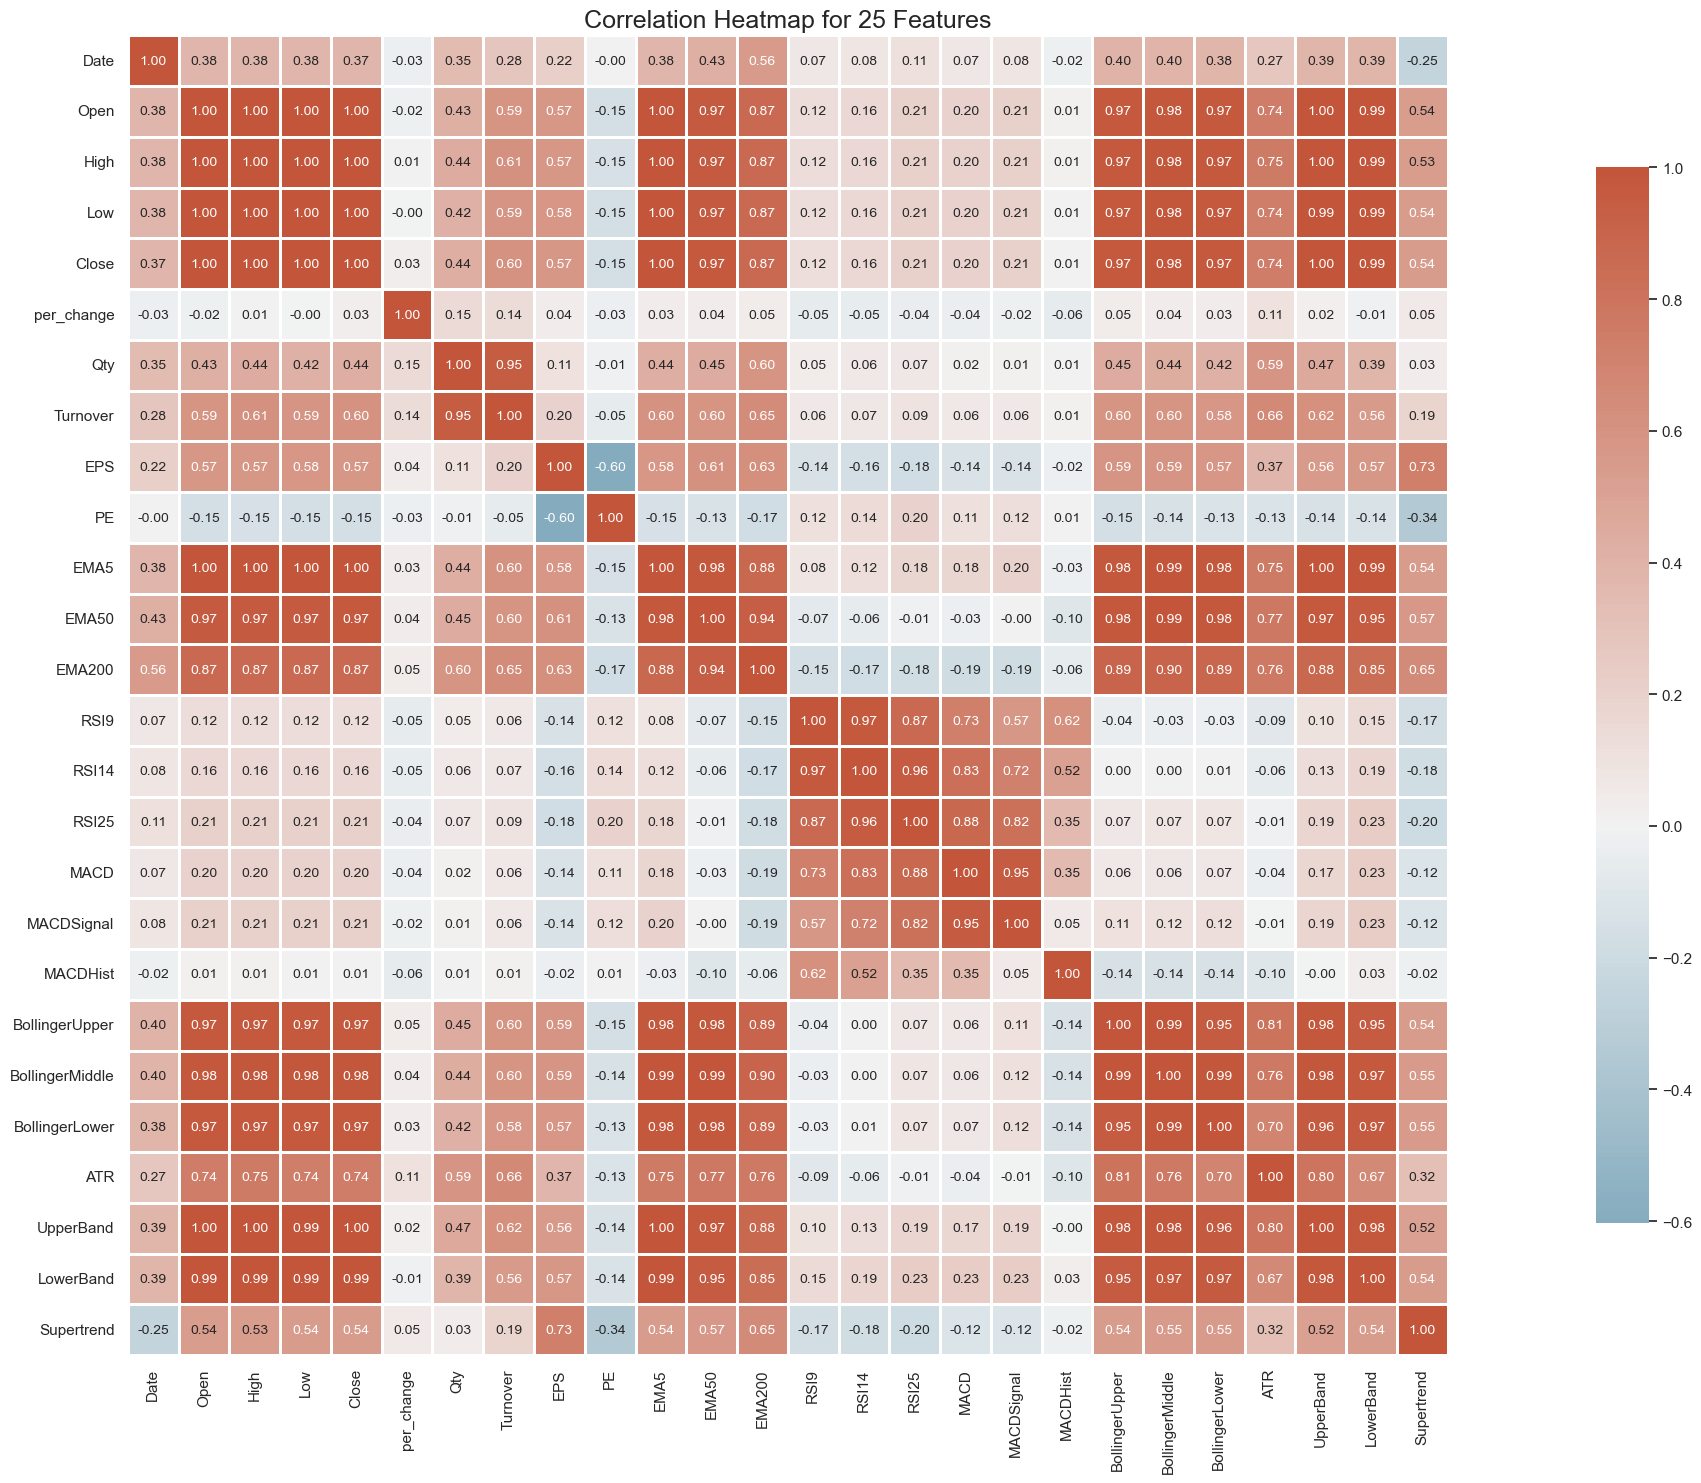

In [34]:
# Step 1: Calculate the correlation matrix
corr_matrix = df.corr()

# Step 2: Plot the heatmap using Seaborn
plt.figure(figsize=(30, 15))  # Adjust size as per your dataset

# Create a custom diverging color palette
sns.set(style="white")  # Set style for better presentation
cmap = sns.diverging_palette(230, 20, as_cmap=True)  # Diverging color map

# Create heatmap with annotation and color intensity
sns.heatmap(corr_matrix, 
            annot=True,             # Annotate the values
            cmap=cmap,              # Use diverging palette for better clarity
            center=0,               # Center the colors around 0
            square=True,            # Square-shaped grid
            linewidths=0.8,         # Line width between cells
            fmt=".2f",              # Formatting for correlation values
            cbar_kws={"shrink": 0.8},  # Adjust color bar size
            annot_kws={"size": 10})    # Font size of annotations

# Step 3: Title and display the plot
plt.title('Correlation Heatmap for 25 Features', fontsize=18)
plt.tight_layout()  # Make sure everything fits
plt.show()

In [35]:
# Plot the heatmap using Seaborn

correlation_matrix = df.corr(numeric_only=True)
print(correlation_matrix)


                     Open      High       Low     Close  per_change       Qty  \
Open             1.000000  0.998964  0.998950  0.997971   -0.020072  0.429891   
High             0.998964  1.000000  0.998768  0.999156    0.006786  0.443407   
Low              0.998950  0.998768  1.000000  0.999125   -0.001953  0.422456   
Close            0.997971  0.999156  0.999125  1.000000    0.025951  0.435302   
per_change      -0.020072  0.006786 -0.001953  0.025951    1.000000  0.153402   
Qty              0.429891  0.443407  0.422456  0.435302    0.153402  1.000000   
Turnover         0.594812  0.606951  0.588467  0.600063    0.137353  0.946201   
EPS              0.570452  0.570210  0.575241  0.573892    0.039453  0.105859   
PE              -0.152502 -0.151590 -0.153660 -0.153434   -0.028654 -0.014308   
EMA5             0.995869  0.997180  0.997270  0.998218    0.031422  0.435626   
EMA50            0.966926  0.968421  0.967957  0.969068    0.036618  0.448971   
EMA200           0.867822  0

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1920 entries, 0 to 1919
Data columns (total 26 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             1920 non-null   datetime64[ns]
 1   Open             1920 non-null   float64       
 2   High             1920 non-null   float64       
 3   Low              1920 non-null   float64       
 4   Close            1920 non-null   float64       
 5   per_change       1920 non-null   float64       
 6   Qty              1920 non-null   int64         
 7   Turnover         1920 non-null   float64       
 8   EPS              1920 non-null   float64       
 9   PE               1920 non-null   float64       
 10  EMA5             1916 non-null   float64       
 11  EMA50            1871 non-null   float64       
 12  EMA200           1721 non-null   float64       
 13  RSI9             1911 non-null   float64       
 14  RSI14            1906 non-null   float64

In [37]:
df1=df.to_csv("updatedNIC.csv", index=False)


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1920 entries, 0 to 1919
Data columns (total 26 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             1920 non-null   datetime64[ns]
 1   Open             1920 non-null   float64       
 2   High             1920 non-null   float64       
 3   Low              1920 non-null   float64       
 4   Close            1920 non-null   float64       
 5   per_change       1920 non-null   float64       
 6   Qty              1920 non-null   int64         
 7   Turnover         1920 non-null   float64       
 8   EPS              1920 non-null   float64       
 9   PE               1920 non-null   float64       
 10  EMA5             1916 non-null   float64       
 11  EMA50            1871 non-null   float64       
 12  EMA200           1721 non-null   float64       
 13  RSI9             1911 non-null   float64       
 14  RSI14            1906 non-null   float64

In [39]:
df1=pd.read_csv("updatedNIC.csv")

In [40]:
df1.head()

,Date,Open,High,Low,Close,per_change,Qty,Turnover,EPS,PE,...,MACD,MACDSignal,MACDHist,BollingerUpper,BollingerMiddle,BollingerLower,ATR,UpperBand,LowerBand,Supertrend
0,2025-02-20,384.5,384.5,373.6,374.5,-0.66,42089,15847811.6,2.04,183.578431,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
1,2025-02-18,389.0,389.6,375.0,377.0,-1.31,74518,28374584.9,2.04,184.803922,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2,2025-02-17,371.0,386.9,370.7,382.0,3.05,108899,41212054.5,2.04,187.254902,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
3,2025-02-16,367.0,370.9,365.0,370.7,2.12,70533,26014490.4,2.04,181.715686,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
4,2025-02-13,360.0,366.0,360.0,363.0,-0.03,47627,17318839.0,2.04,177.941177,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0


In [41]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1920 entries, 0 to 1919
Data columns (total 26 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date             1920 non-null   object 
 1   Open             1920 non-null   float64
 2   High             1920 non-null   float64
 3   Low              1920 non-null   float64
 4   Close            1920 non-null   float64
 5   per_change       1920 non-null   float64
 6   Qty              1920 non-null   int64  
 7   Turnover         1920 non-null   float64
 8   EPS              1920 non-null   float64
 9   PE               1920 non-null   float64
 10  EMA5             1916 non-null   float64
 11  EMA50            1871 non-null   float64
 12  EMA200           1721 non-null   float64
 13  RSI9             1911 non-null   float64
 14  RSI14            1906 non-null   float64
 15  RSI25            1895 non-null   float64
 16  MACD             1887 non-null   float64
 17  MACDSignal    

In [42]:
#df=original,df1=copied,df2=dropped percent_change

In [43]:
df2=df1.drop("per_change", axis=1)

In [44]:
df2.head()

,Date,Open,High,Low,Close,Qty,Turnover,EPS,PE,EMA5,...,MACD,MACDSignal,MACDHist,BollingerUpper,BollingerMiddle,BollingerLower,ATR,UpperBand,LowerBand,Supertrend
0,2025-02-20,384.5,384.5,373.6,374.5,42089,15847811.6,2.04,183.578431,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
1,2025-02-18,389.0,389.6,375.0,377.0,74518,28374584.9,2.04,184.803922,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2,2025-02-17,371.0,386.9,370.7,382.0,108899,41212054.5,2.04,187.254902,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
3,2025-02-16,367.0,370.9,365.0,370.7,70533,26014490.4,2.04,181.715686,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
4,2025-02-13,360.0,366.0,360.0,363.0,47627,17318839.0,2.04,177.941177,373.44,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0


In [45]:
df2['Date'] = pd.to_datetime(df2['Date']) 
df2.set_index('Date', inplace=True)

In [46]:
df2.head()

,Open,High,Low,Close,Qty,Turnover,EPS,PE,EMA5,EMA50,...,MACD,MACDSignal,MACDHist,BollingerUpper,BollingerMiddle,BollingerLower,ATR,UpperBand,LowerBand,Supertrend
Date,,,,,,,,,,,,,,,,,,,,,
2025-02-20,384.5,384.5,373.6,374.5,42089,15847811.6,2.04,183.578431,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2025-02-18,389.0,389.6,375.0,377.0,74518,28374584.9,2.04,184.803922,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2025-02-17,371.0,386.9,370.7,382.0,108899,41212054.5,2.04,187.254902,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2025-02-16,367.0,370.9,365.0,370.7,70533,26014490.4,2.04,181.715686,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2025-02-13,360.0,366.0,360.0,363.0,47627,17318839.0,2.04,177.941177,373.44,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0


In [47]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1920 entries, 2025-02-20 to 2016-10-16
Data columns (total 24 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Open             1920 non-null   float64
 1   High             1920 non-null   float64
 2   Low              1920 non-null   float64
 3   Close            1920 non-null   float64
 4   Qty              1920 non-null   int64  
 5   Turnover         1920 non-null   float64
 6   EPS              1920 non-null   float64
 7   PE               1920 non-null   float64
 8   EMA5             1916 non-null   float64
 9   EMA50            1871 non-null   float64
 10  EMA200           1721 non-null   float64
 11  RSI9             1911 non-null   float64
 12  RSI14            1906 non-null   float64
 13  RSI25            1895 non-null   float64
 14  MACD             1887 non-null   float64
 15  MACDSignal       1887 non-null   float64
 16  MACDHist         1887 non-null   float64
 

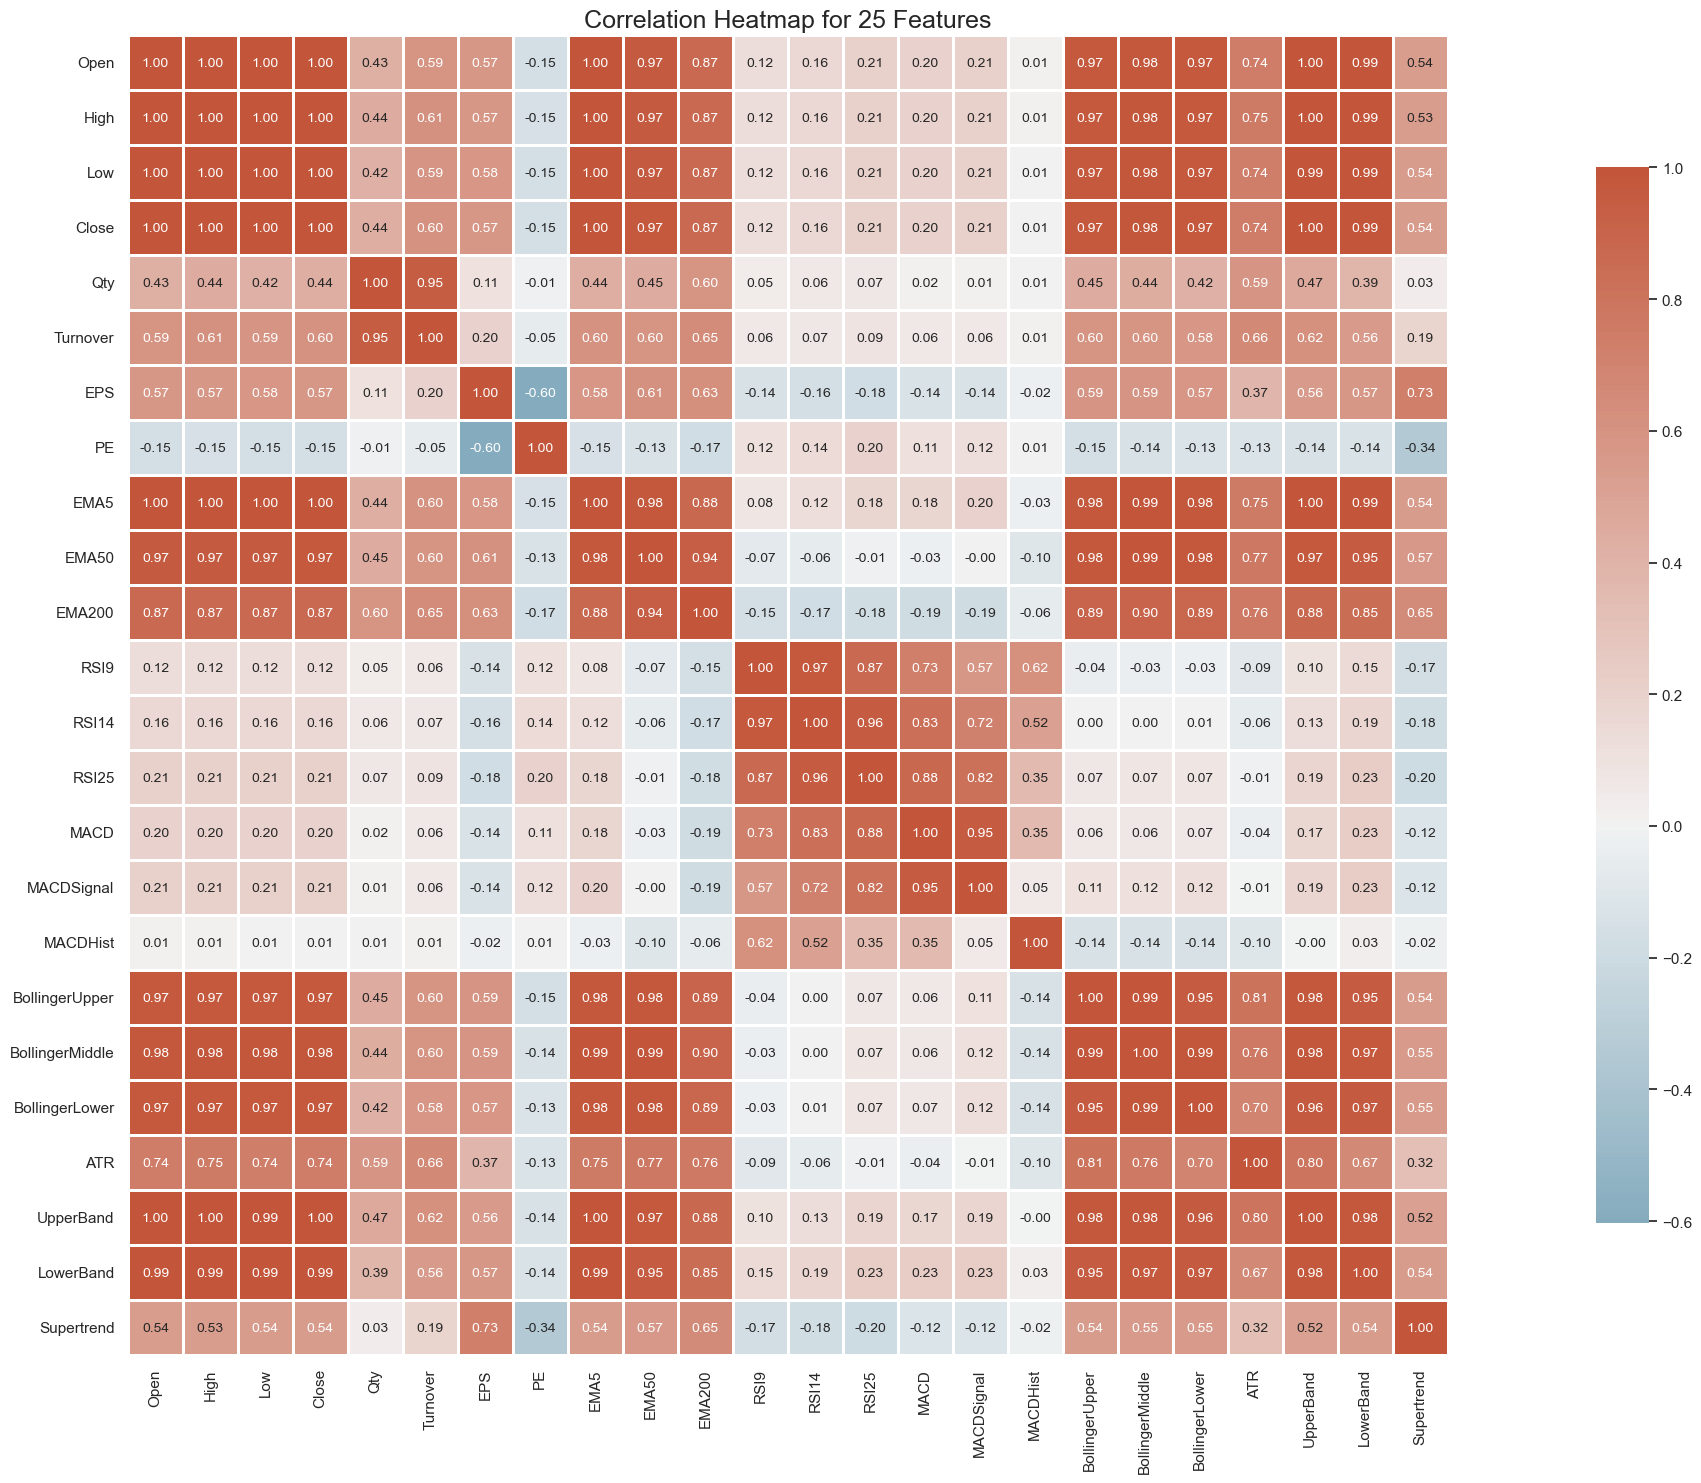

In [48]:
# Step 1: Calculate the correlation matrix
corr_matrix = df2.corr()

# Step 2: Plot the heatmap using Seaborn
plt.figure(figsize=(30, 15))  # Adjust size as per your dataset

# Create a custom diverging color palette
sns.set(style="white")  # Set style for better presentation
cmap = sns.diverging_palette(230, 20, as_cmap=True)  # Diverging color map

# Create heatmap with annotation and color intensity
sns.heatmap(corr_matrix, 
            annot=True,             # Annotate the values
            cmap=cmap,              # Use diverging palette for better clarity
            center=0,               # Center the colors around 0
            square=True,            # Square-shaped grid
            linewidths=0.8,         # Line width between cells
            fmt=".2f",              # Formatting for correlation values
            cbar_kws={"shrink": 0.8},  # Adjust color bar size
            annot_kws={"size": 10})    # Font size of annotations

# Step 3: Title and display the plot
plt.title('Correlation Heatmap for 25 Features', fontsize=18)
plt.tight_layout()  # Make sure everything fits
plt.show()

In [49]:
# df['PercentChange'] = df['PercentChange'].astype(float)
# df['PercentChange'].iloc[[0,1,1001]] 
# df["Date"] = df["Date"].str.replace('[\\/]', '', regex=True)

# df['Date'] = df['Date'].astype(int)
# print(df)


In [50]:
df2.isna().sum()

Open                 0
High                 0
Low                  0
Close                0
Qty                  0
Turnover             0
EPS                  0
PE                   0
EMA5                 4
EMA50               49
EMA200             199
RSI9                 9
RSI14               14
RSI25               25
MACD                33
MACDSignal          33
MACDHist            33
BollingerUpper      19
BollingerMiddle     19
BollingerLower      19
ATR                 10
UpperBand           10
LowerBand           10
Supertrend           0
dtype: int64

In [51]:
df2.describe().T

,count,mean,std,min,25%,50%,75%,max
Open,1920.0,5.683004e+02,1.929963e+02,295.000000,4.110000e+02,4.980000e+02,7.300000e+02,1.080000e+03
High,1920.0,5.749942e+02,1.949844e+02,303.000000,4.150000e+02,5.050000e+02,7.365250e+02,1.085000e+03
Low,1920.0,5.591054e+02,1.885898e+02,285.000000,4.060000e+02,4.900000e+02,7.200500e+02,1.046000e+03
Close,1920.0,5.660441e+02,1.910360e+02,298.000000,4.100750e+02,4.970000e+02,7.250500e+02,1.073000e+03
Qty,1920.0,7.216372e+04,8.503110e+04,60.000000,1.740175e+04,4.409900e+04,9.155300e+04,7.510750e+05
Turnover,1920.0,4.786418e+07,6.673416e+07,28130.000000,7.768261e+06,2.442911e+07,5.681857e+07,5.601084e+08
EPS,1920.0,3.012615e+01,1.400751e+01,1.780000,1.794000e+01,3.456000e+01,4.022000e+01,6.077000e+01
PE,1920.0,3.235322e+01,4.841371e+01,9.367337,1.466540e+01,1.872428e+01,2.468794e+01,2.859551e+02
EMA5,1916.0,5.661587e+02,1.906043e+02,305.249828,4.111470e+02,4.961479e+02,7.261343e+02,1.054211e+03
EMA50,1871.0,5.684018e+02,1.861909e+02,323.443880,4.176656e+02,4.860224e+02,7.339652e+02,9.749986e+02


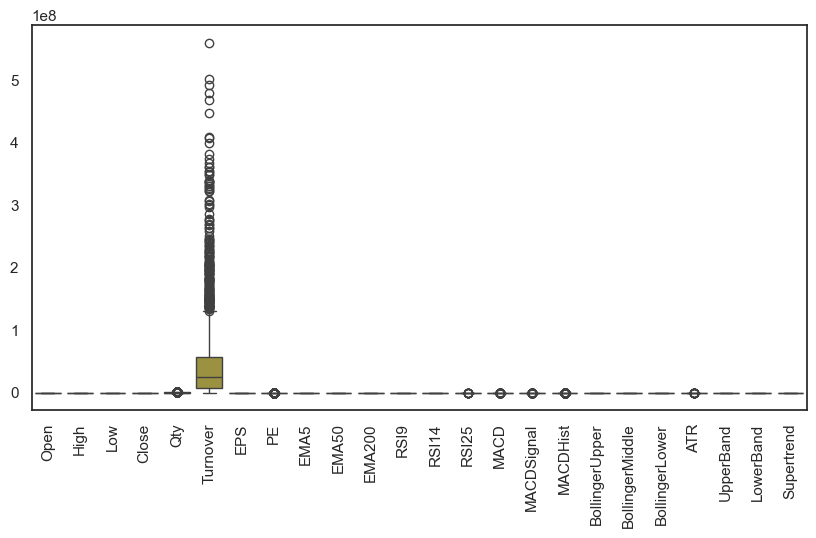

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.boxplot(data=df2)
plt.xticks(rotation=90)  # Rotate x-axis labels for readability
plt.show()


In [53]:
# print(df2['ATR'].value_counts())


In [54]:
df2.isna().sum()

Open                 0
High                 0
Low                  0
Close                0
Qty                  0
Turnover             0
EPS                  0
PE                   0
EMA5                 4
EMA50               49
EMA200             199
RSI9                 9
RSI14               14
RSI25               25
MACD                33
MACDSignal          33
MACDHist            33
BollingerUpper      19
BollingerMiddle     19
BollingerLower      19
ATR                 10
UpperBand           10
LowerBand           10
Supertrend           0
dtype: int64

In [55]:
df2.drop(columns=["EMA5", "EMA50", "EMA200","UpperBand","LowerBand","Supertrend"], inplace=True)


df2.head()

,Open,High,Low,Close,Qty,Turnover,EPS,PE,RSI9,RSI14,RSI25,MACD,MACDSignal,MACDHist,BollingerUpper,BollingerMiddle,BollingerLower,ATR
Date,,,,,,,,,,,,,,,,,,
2025-02-20,384.5,384.5,373.6,374.5,42089,15847811.6,2.04,183.578431,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-02-18,389.0,389.6,375.0,377.0,74518,28374584.9,2.04,184.803922,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-02-17,371.0,386.9,370.7,382.0,108899,41212054.5,2.04,187.254902,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-02-16,367.0,370.9,365.0,370.7,70533,26014490.4,2.04,181.715686,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-02-13,360.0,366.0,360.0,363.0,47627,17318839.0,2.04,177.941177,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [56]:
# # df2['Weekday'] = df2.index.weekday
# # df2['Weekday'] = df2.index.weekday
# df2['Weekday'] = df2['Weekday'].apply(lambda x: (x + 1) % 7 if x < 5 else 0)
# df2.head(20)

In [57]:
df2.isna().sum()

Open                0
High                0
Low                 0
Close               0
Qty                 0
Turnover            0
EPS                 0
PE                  0
RSI9                9
RSI14              14
RSI25              25
MACD               33
MACDSignal         33
MACDHist           33
BollingerUpper     19
BollingerMiddle    19
BollingerLower     19
ATR                10
dtype: int64

In [58]:
# First, forward fill any missing values
df3 = df2.bfill()






In [59]:
df3.head()

,Open,High,Low,Close,Qty,Turnover,EPS,PE,RSI9,RSI14,RSI25,MACD,MACDSignal,MACDHist,BollingerUpper,BollingerMiddle,BollingerLower,ATR
Date,,,,,,,,,,,,,,,,,,
2025-02-20,384.5,384.5,373.6,374.5,42089,15847811.6,2.04,183.578431,35.472973,33.333333,52.968037,4.546487,2.564434,1.982053,380.012712,366.245,352.477288,11.22
2025-02-18,389.0,389.6,375.0,377.0,74518,28374584.9,2.04,184.803922,35.472973,33.333333,52.968037,4.546487,2.564434,1.982053,380.012712,366.245,352.477288,11.22
2025-02-17,371.0,386.9,370.7,382.0,108899,41212054.5,2.04,187.254902,35.472973,33.333333,52.968037,4.546487,2.564434,1.982053,380.012712,366.245,352.477288,11.22
2025-02-16,367.0,370.9,365.0,370.7,70533,26014490.4,2.04,181.715686,35.472973,33.333333,52.968037,4.546487,2.564434,1.982053,380.012712,366.245,352.477288,11.22
2025-02-13,360.0,366.0,360.0,363.0,47627,17318839.0,2.04,177.941177,35.472973,33.333333,52.968037,4.546487,2.564434,1.982053,380.012712,366.245,352.477288,11.22


In [60]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1920 entries, 2025-02-20 to 2016-10-16
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Open             1920 non-null   float64
 1   High             1920 non-null   float64
 2   Low              1920 non-null   float64
 3   Close            1920 non-null   float64
 4   Qty              1920 non-null   int64  
 5   Turnover         1920 non-null   float64
 6   EPS              1920 non-null   float64
 7   PE               1920 non-null   float64
 8   RSI9             1920 non-null   float64
 9   RSI14            1920 non-null   float64
 10  RSI25            1920 non-null   float64
 11  MACD             1920 non-null   float64
 12  MACDSignal       1920 non-null   float64
 13  MACDHist         1920 non-null   float64
 14  BollingerUpper   1920 non-null   float64
 15  BollingerMiddle  1920 non-null   float64
 16  BollingerLower   1920 non-null   float64
 

In [61]:
df3.isna().sum()

Open               0
High               0
Low                0
Close              0
Qty                0
Turnover           0
EPS                0
PE                 0
RSI9               0
RSI14              0
RSI25              0
MACD               0
MACDSignal         0
MACDHist           0
BollingerUpper     0
BollingerMiddle    0
BollingerLower     0
ATR                0
dtype: int64

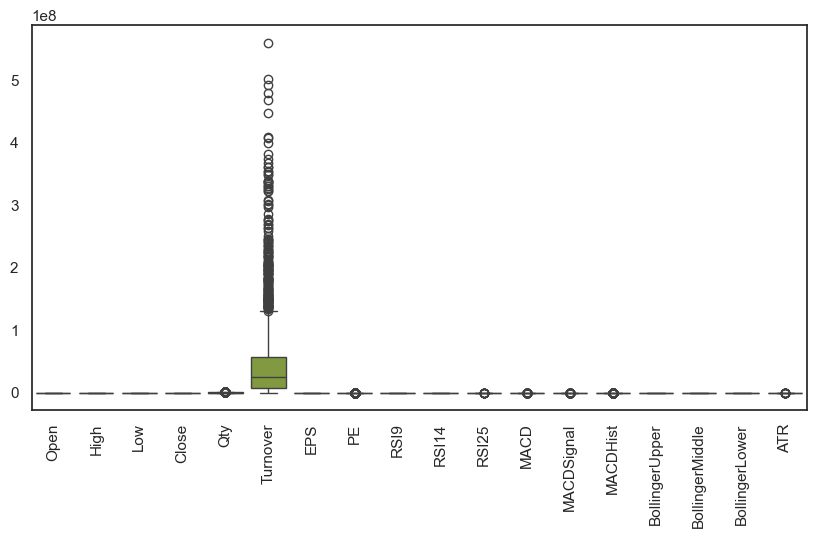

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.boxplot(data=df3)
plt.xticks(rotation=90)  # Rotate x-axis labels for readability
plt.show()

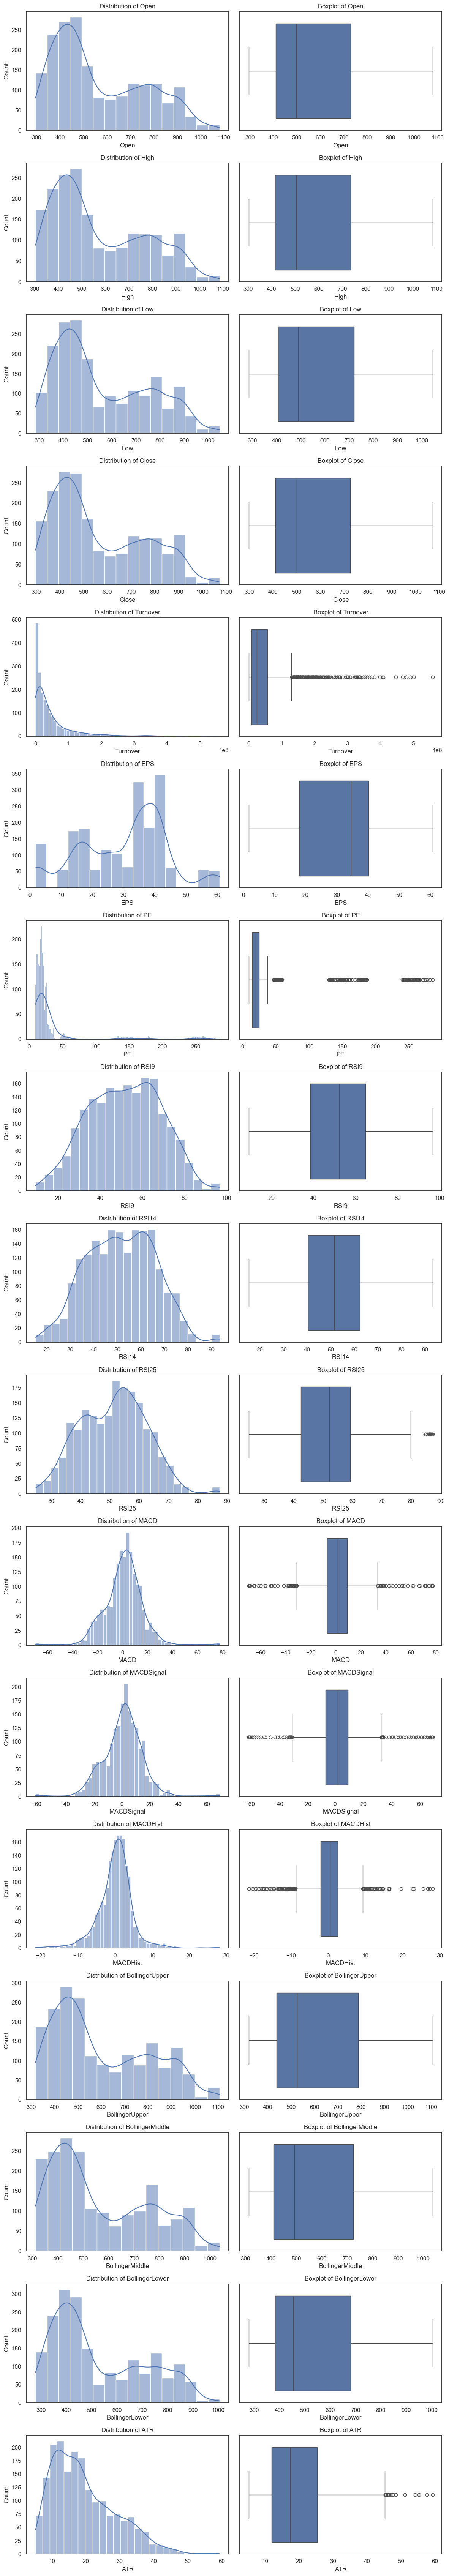

In [63]:

# Calculate rows needed based on the number of columns
numerical_data = df3.select_dtypes(include=['float64'])
n_cols = len(numerical_data.columns)
n_rows = n_cols

# Adjust figsize dynamically
plt.figure(figsize=(12, 4 * n_rows))

for i, col in enumerate(numerical_data.columns):
    # Create a subplot for the distribution plot
    plt.subplot(n_rows, 2, 2 * i + 1)
    # sns.histplot(numerical_data[col], kde=True, bins=30)  # Updated to use sns.histplot
    sns.histplot(df3[col], kde=True)
    plt.title(f'Distribution of {col}')
     # Create a subplot for the boxplot
    plt.subplot(n_rows, 2, 2 * i + 2)
    sns.boxplot(x=numerical_data[col])
    plt.title(f'Boxplot of {col}')

# Adjustjustment on  layout to prevent overlap
plt.tight_layout()
plt.show()

In [64]:
def find_outliers_iqr_multiple_columns(df3,columns):
    """
    Identify outliers in multiple specified columns of a data frame using the IQR method.
    """
    outliers_summary = {}

    for column in columns:

        percentile25 = df3[column].quantile(0.25)
        percentile75 = df3[column].quantile(0.75)
        iqr = percentile75 - percentile25
        lower_limit = percentile25 - 1.5 * iqr
        upper_limit = percentile75 + 1.5 * iqr


        lower_outliers = df3[df3[column] < lower_limit]
        upper_outliers = df3[df3[column] > upper_limit]

        outliers_summary[column] = {
            'lower_outliers_count': len(lower_outliers),
            'upper_outliers_count': len(upper_outliers),
            'lower_limit': lower_limit,
            'upper_limit': upper_limit
        }

    return outliers_summary
columns = df3.select_dtypes(include=['float64', 'int64'])
outliers_summary = find_outliers_iqr_multiple_columns(df3, columns)


for column, summary in outliers_summary.items():
    print(f"\nColumn: {column}")
    print(f"Lower Outliers Count: {summary['lower_outliers_count']}")
    print(f"Upper Outliers Count: {summary['upper_outliers_count']}")
    print(f"Lower Limit: {summary['lower_limit']}")
    print(f"Upper Limit: {summary['upper_limit']}")


Column: Open
Lower Outliers Count: 0
Upper Outliers Count: 0
Lower Limit: -67.5
Upper Limit: 1208.5

Column: High
Lower Outliers Count: 0
Upper Outliers Count: 0
Lower Limit: -67.28749999999997
Upper Limit: 1218.8125

Column: Low
Lower Outliers Count: 0
Upper Outliers Count: 0
Lower Limit: -65.07499999999993
Upper Limit: 1191.125

Column: Close
Lower Outliers Count: 0
Upper Outliers Count: 0
Lower Limit: -62.38749999999982
Upper Limit: 1197.5124999999998

Column: Qty
Lower Outliers Count: 0
Upper Outliers Count: 139
Lower Limit: -93825.125
Upper Limit: 202779.875

Column: Turnover
Lower Outliers Count: 0
Upper Outliers Count: 169
Lower Limit: -65807201.375
Upper Limit: 130394031.625

Column: EPS
Lower Outliers Count: 0
Upper Outliers Count: 0
Lower Limit: -15.479999999999993
Upper Limit: 73.63999999999999

Column: PE
Lower Outliers Count: 0
Upper Outliers Count: 193
Lower Limit: -0.368411862499995
Upper Limit: 39.721755877499994

Column: RSI9
Lower Outliers Count: 0
Upper Outliers Cou

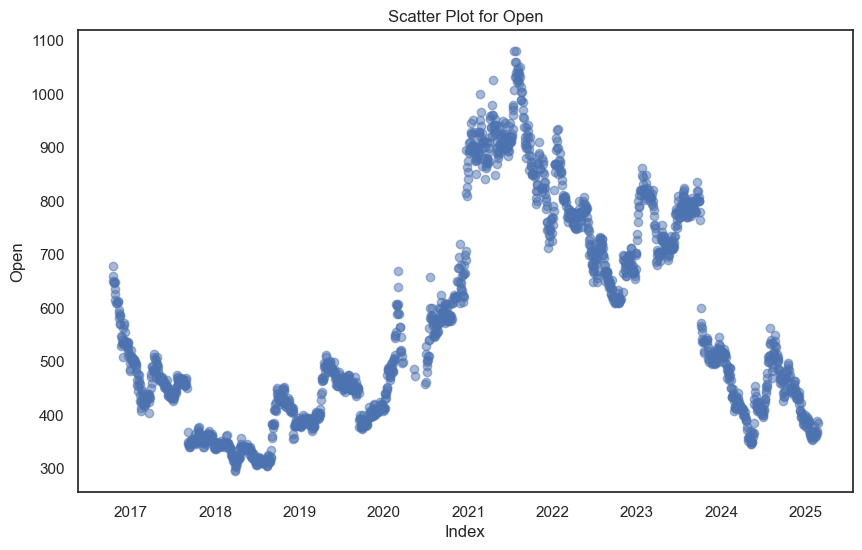

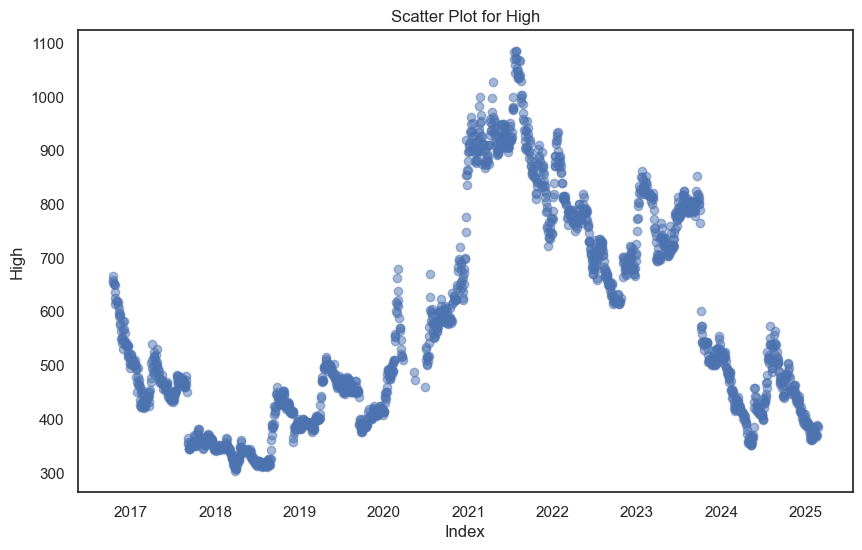

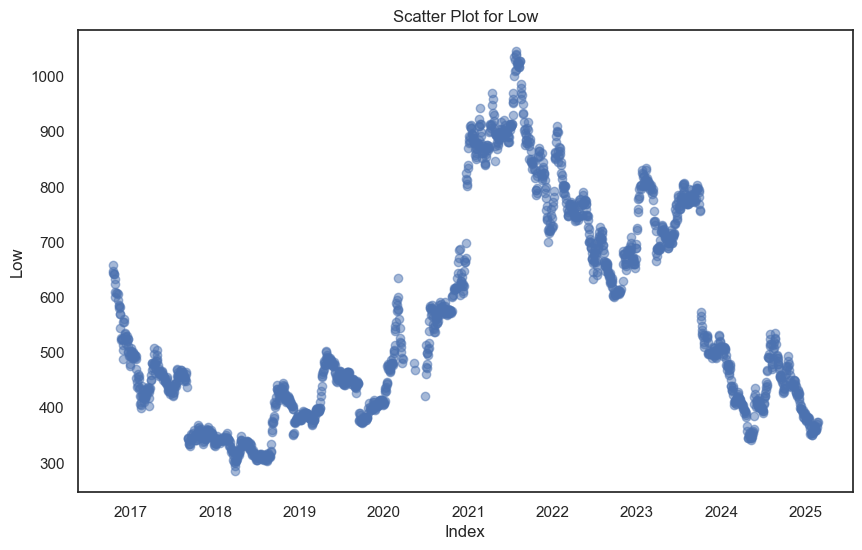

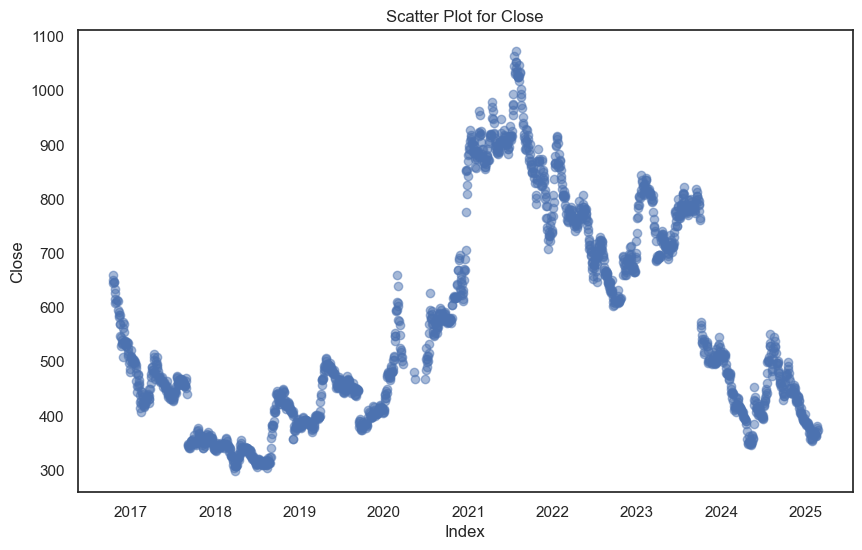

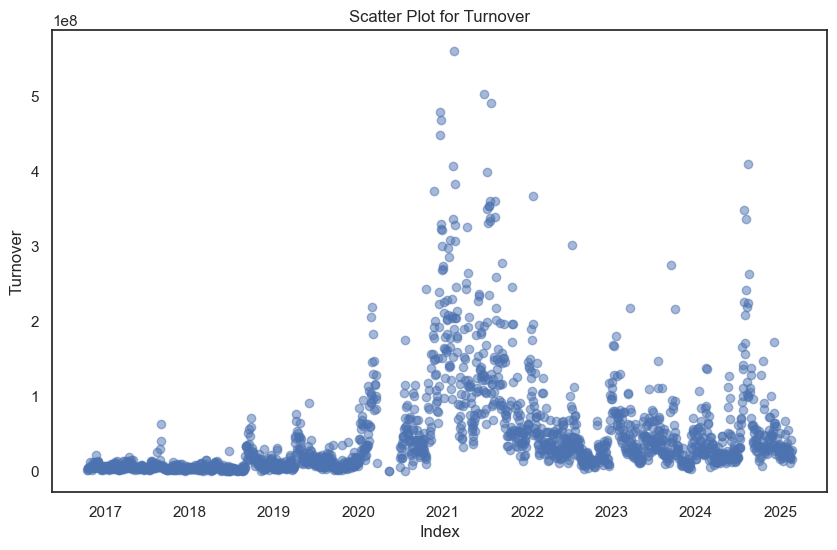

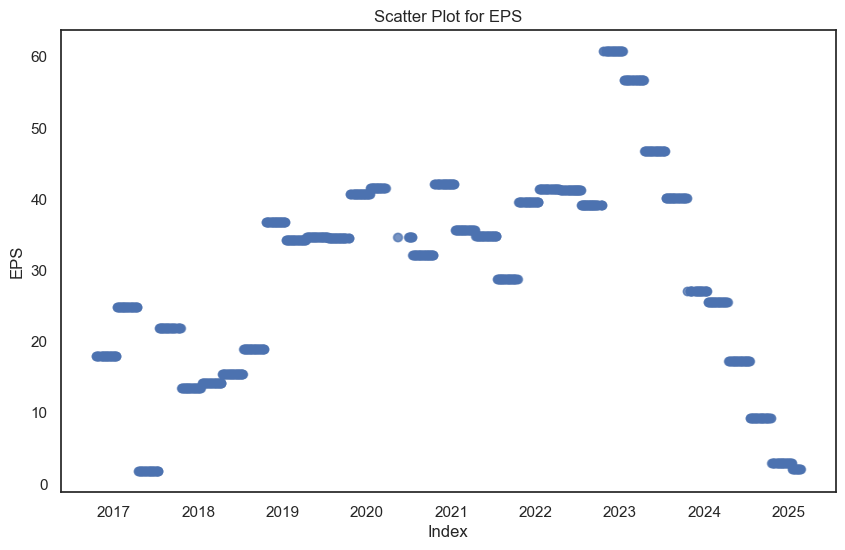

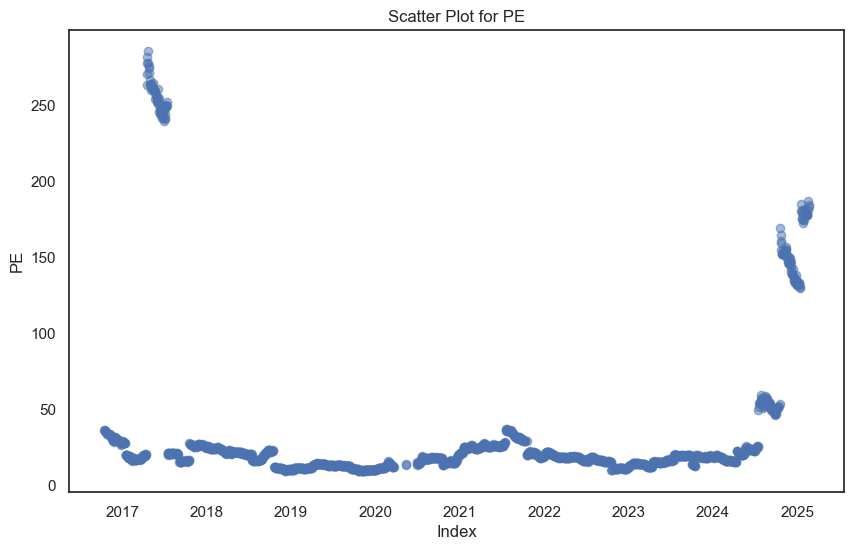

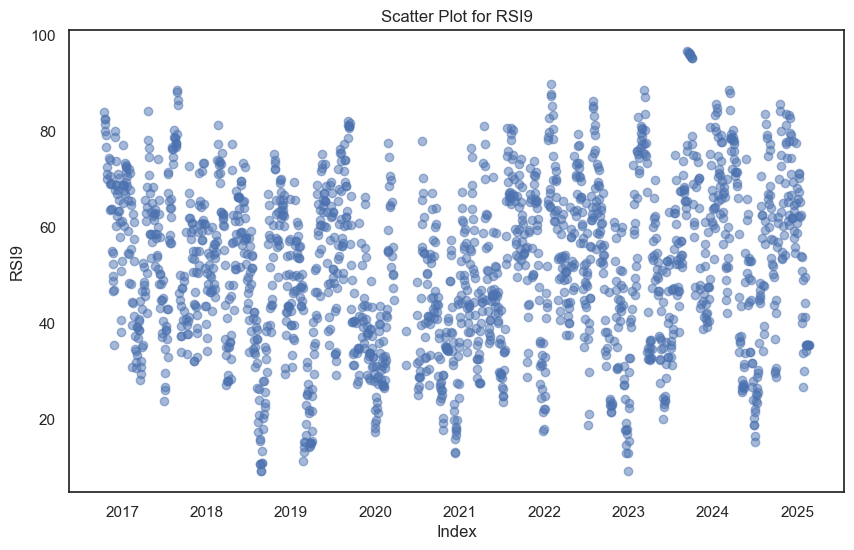

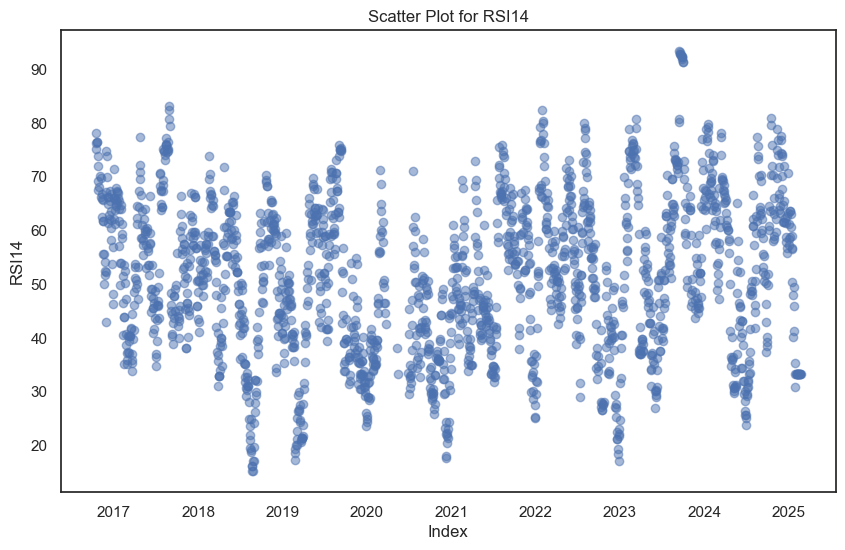

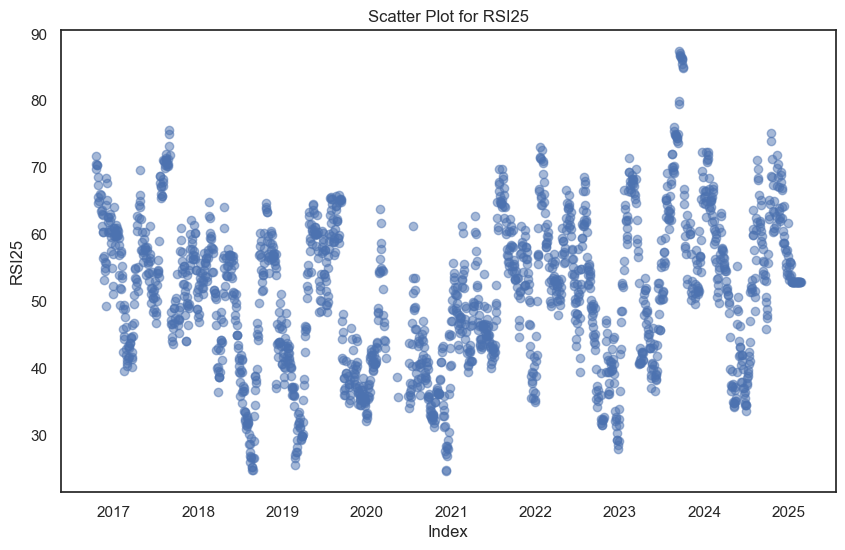

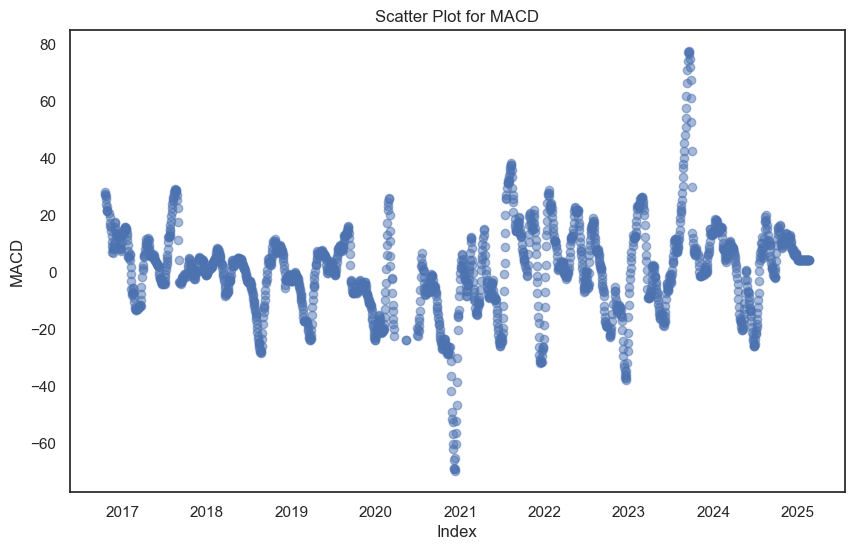

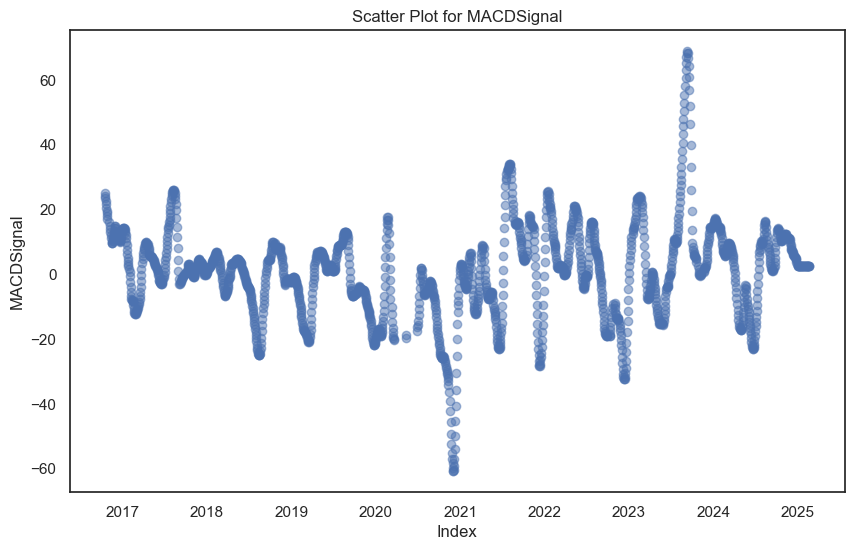

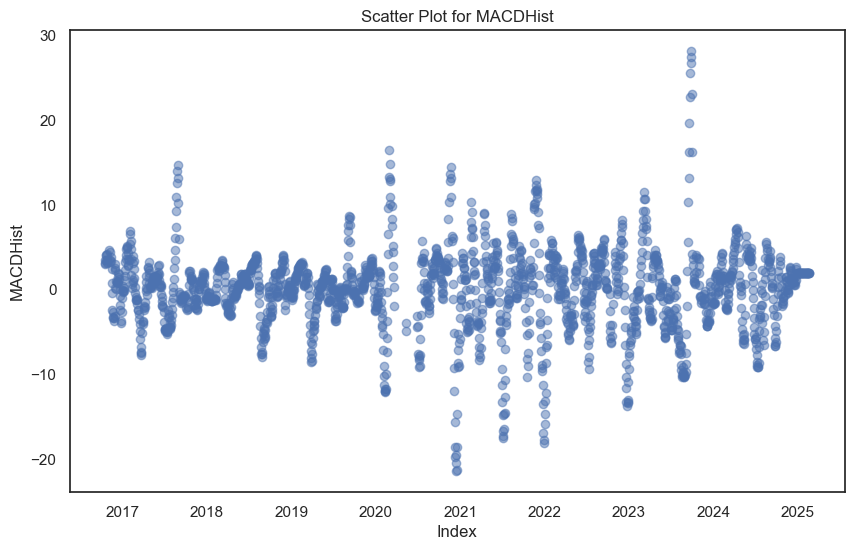

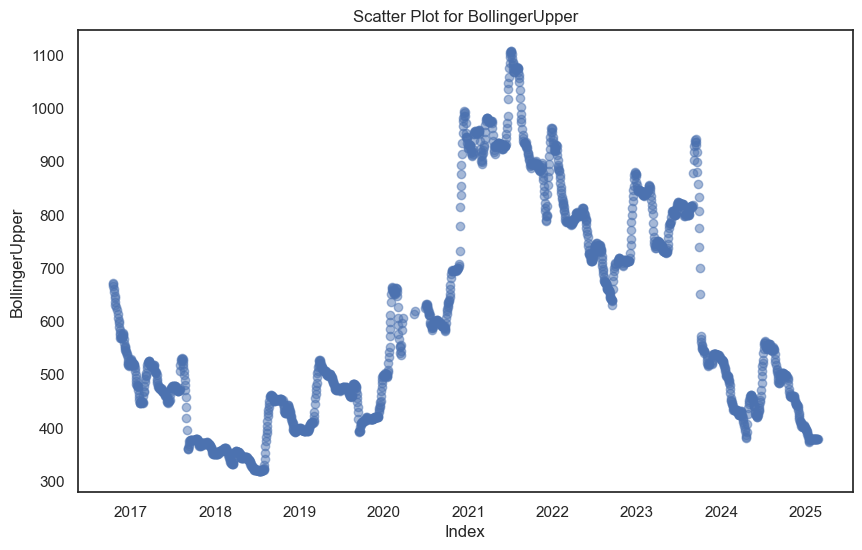

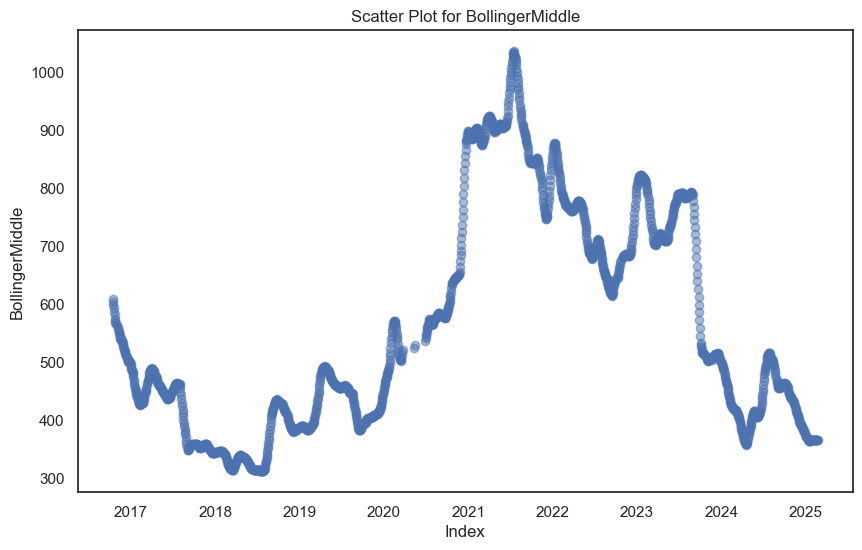

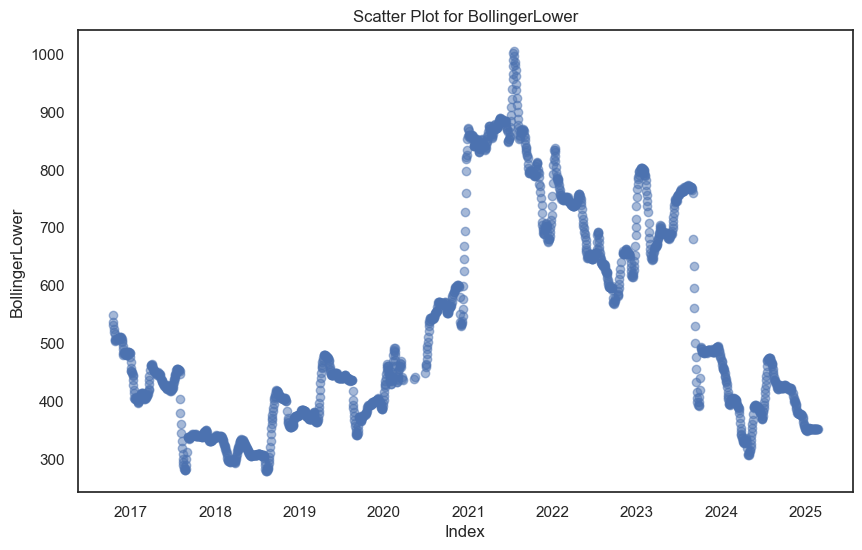

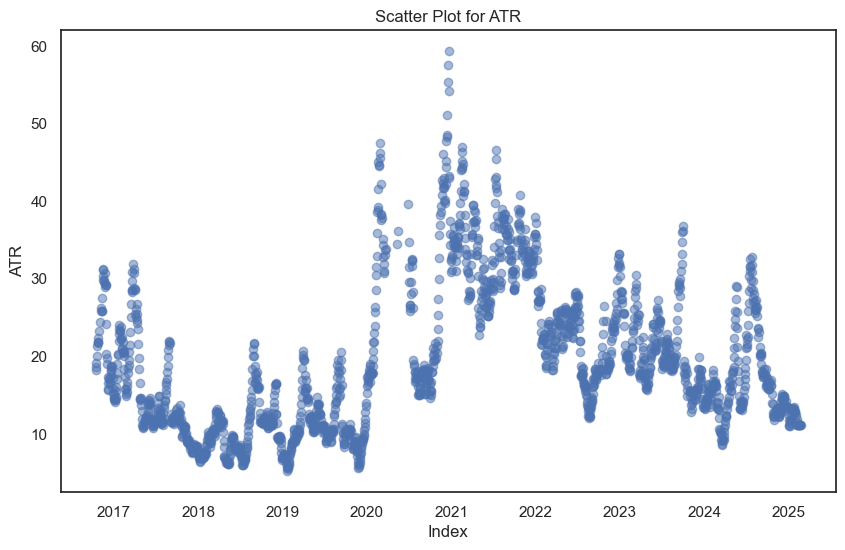

In [65]:
import matplotlib.pyplot as plt

# Plot scatter plot for each numerical column to check for outliers
for column in numerical_data.columns:
    plt.figure(figsize=(10, 6))
    plt.scatter(df3.index, df3[column], alpha=0.5)
    plt.title(f'Scatter Plot for {column}')
    plt.xlabel('Index')
    plt.ylabel(column)
    plt.show()

In [66]:
# def detect_outliers_iqr(data, column):
#     Q1 = data[column].quantile(0.25)
#     Q3 = data[column].quantile(0.75)
#     IQR = Q3 - Q1
#     lower_bound = Q1 - 1.5 * IQR
#     upper_bound = Q3 + 1.5 * IQR
#     outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
#     return outliers

# # Check for outliers in stock prices
# for col in df3:
#     outliers = detect_outliers_iqr(df3, col)
#     print(f"{col} - Outliers Found: {len(outliers)}")


In [67]:
# # Function to detect outliers using IQR
# def detect_outliers_iqr(data, column):
#     Q1 = data[column].quantile(0.25)
#     Q3 = data[column].quantile(0.75)
#     IQR = Q3 - Q1
#     lower_bound = Q1 - 1.5 * IQR
#     upper_bound = Q3 + 1.5 * IQR
#     outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
#     return outliers

# # Display outliers for each column
# for col in df2.columns:
#     outliers = detect_outliers_iqr(df2, col)
#     if not outliers.empty:
#         print(f"Outliers in {col}:")
#         print(outliers)
#         print("\n")

In [68]:
# for col in df:
#     Q1 = df[col].quantile(0.25)
#     Q3 = df[col].quantile(0.75)
#     IQR = Q3 - Q1
#     lower_bound = Q1 - 1.5 * IQR
#     upper_bound = Q3 + 1.5 * IQR

#     df[col] = df[col].clip(lower_bound, upper_bound)

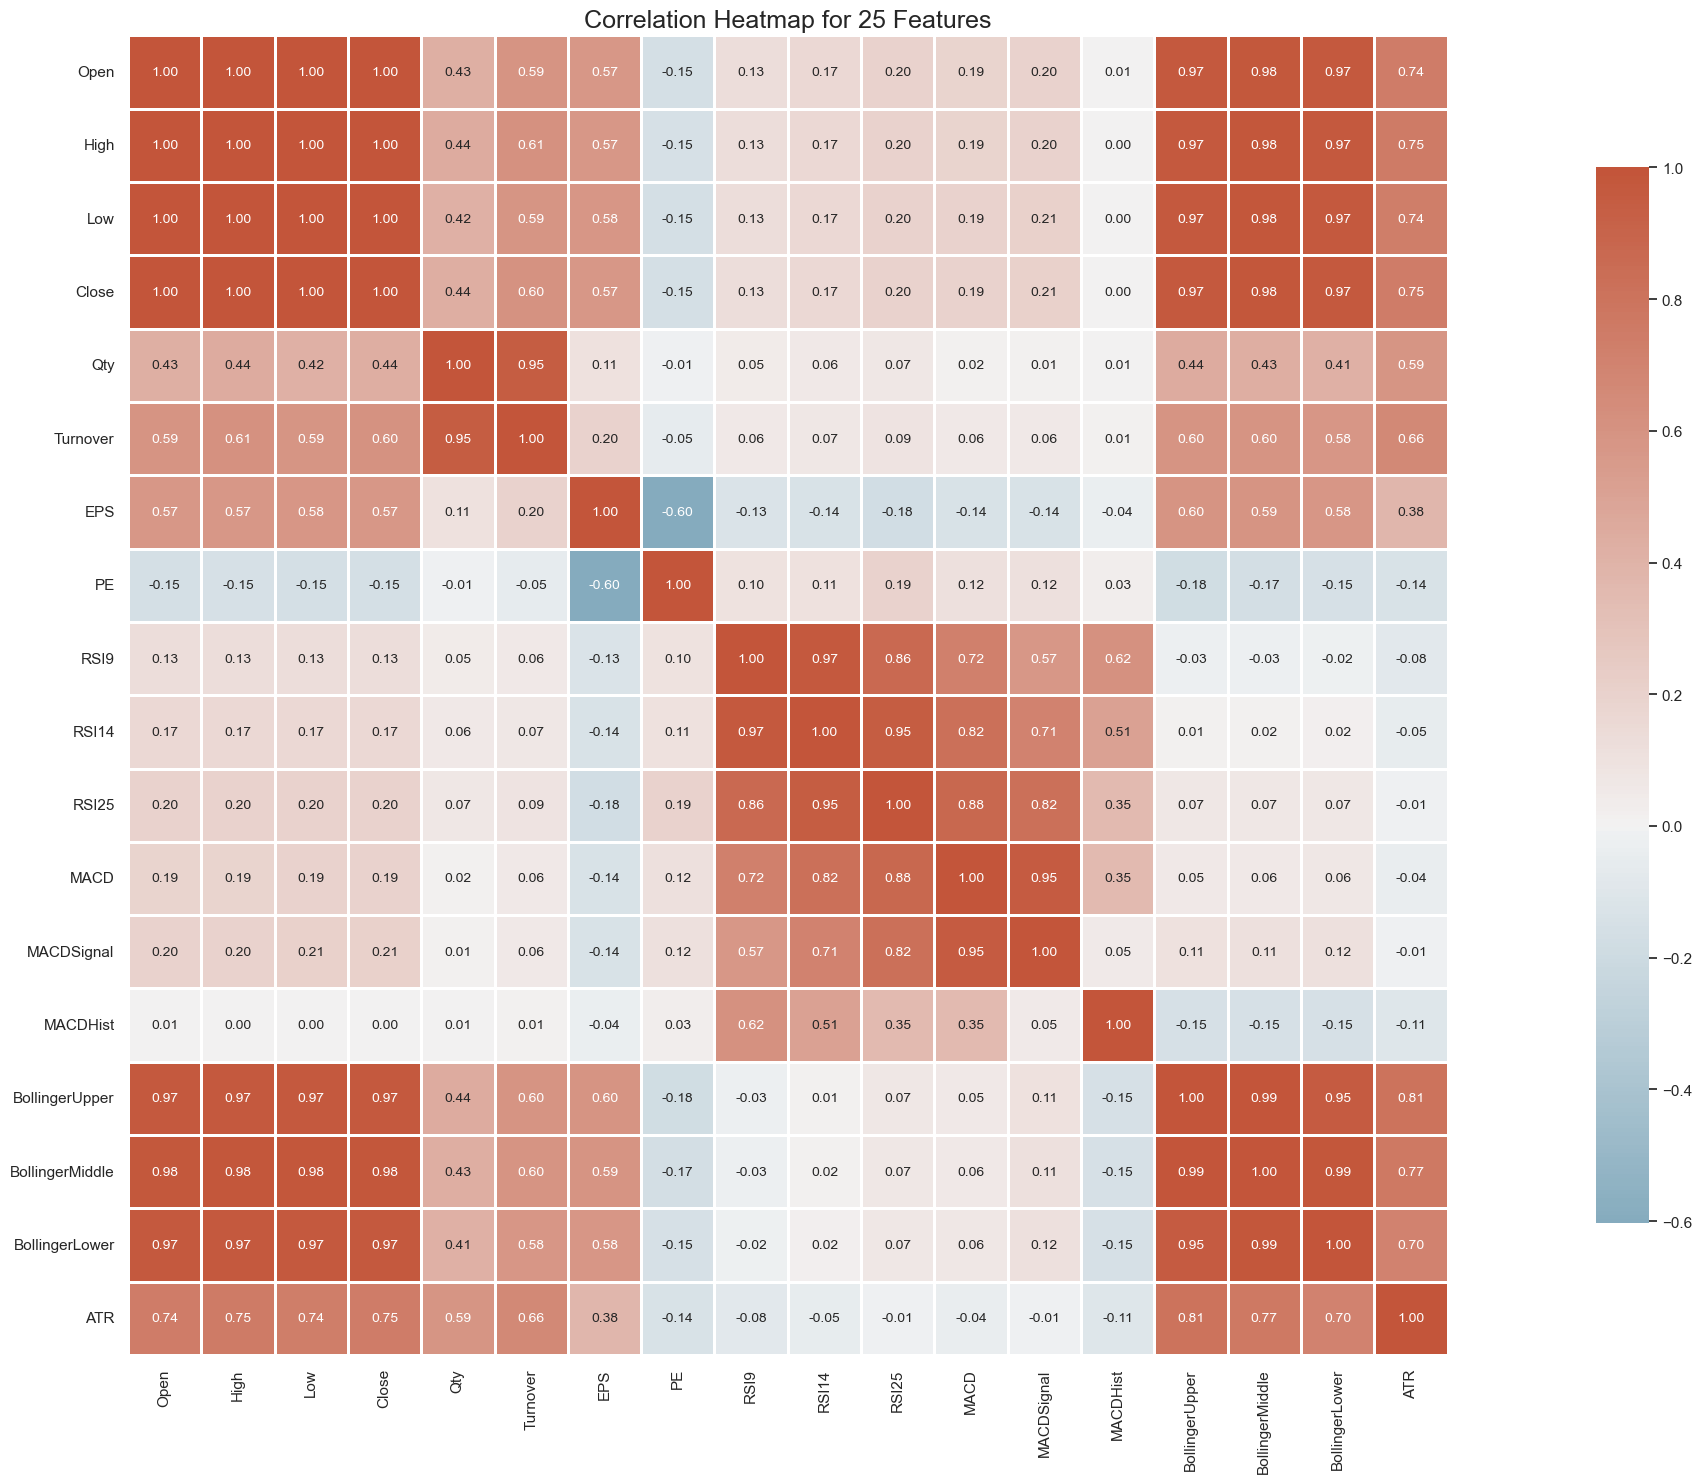

In [69]:
# Step 1: Calculate the correlation matrix
corr_matrix = df3.corr()

# Step 2: Plot the heatmap using Seaborn
plt.figure(figsize=(30, 15))  # Adjust size as per your dataset

# Create a custom diverging color palette
sns.set(style="white")  # Set style for better presentation
cmap = sns.diverging_palette(230, 20, as_cmap=True)  # Diverging color map

# Create heatmap with annotation and color intensity
sns.heatmap(corr_matrix, 
            annot=True,             # Annotate the values
            cmap=cmap,              # Use diverging palette for better clarity
            center=0,               # Center the colors around 0
            square=True,            # Square-shaped grid
            linewidths=0.8,         # Line width between cells
            fmt=".2f",              # Formatting for correlation values
            cbar_kws={"shrink": 0.8},  # Adjust color bar size
            annot_kws={"size": 10})    # Font size of annotations

# Step 3: Title and display the plot
plt.title('Correlation Heatmap for 25 Features', fontsize=18)
plt.tight_layout()  # Make sure everything fits
plt.show()

In [70]:
# from sklearn.preprocessing import MinMaxScaler
# import pandas as pd

# # Initialize the MinMaxScaler
# scaler = MinMaxScaler(feature_range=(0, 1))

# # Fit and transform the data
# df_scaled = scaler.fit_transform(df)  # This returns a NumPy array

# # Convert back to DataFrame (to retain column names and index)
# df = pd.DataFrame(df_scaled, columns=df.columns, index=df.index)

# print(df.head())  # Display first few rows



In [71]:
import pandas as pd

correlation_matrix = df3.corr(numeric_only=True)
print(correlation_matrix)


                     Open      High       Low     Close       Qty  Turnover  \
Open             1.000000  0.998964  0.998950  0.997971  0.429891  0.594812   
High             0.998964  1.000000  0.998768  0.999156  0.443407  0.606951   
Low              0.998950  0.998768  1.000000  0.999125  0.422456  0.588467   
Close            0.997971  0.999156  0.999125  1.000000  0.435302  0.600063   
Qty              0.429891  0.443407  0.422456  0.435302  1.000000  0.946201   
Turnover         0.594812  0.606951  0.588467  0.600063  0.946201  1.000000   
EPS              0.570452  0.570210  0.575241  0.573892  0.105859  0.200788   
PE              -0.152502 -0.151590 -0.153660 -0.153434 -0.014308 -0.054942   
RSI9             0.128918  0.127899  0.127775  0.127266  0.047333  0.060705   
RSI14            0.165751  0.165059  0.165593  0.165015  0.056690  0.073084   
RSI25            0.203903  0.203915  0.204783  0.204339  0.070188  0.086086   
MACD             0.191394  0.190648  0.193415  0.192

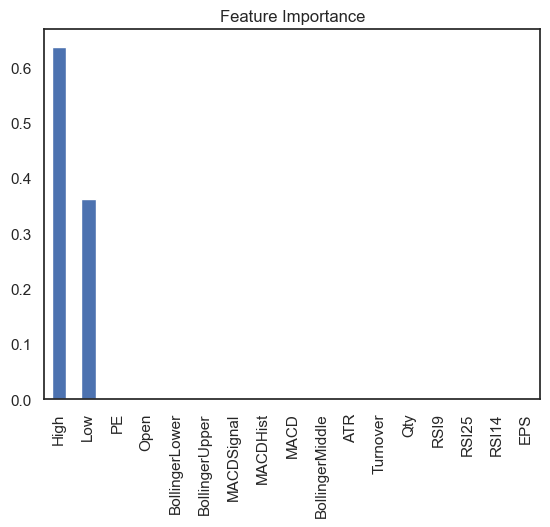

In [72]:
from sklearn.ensemble import RandomForestRegressor

# Select numerical columns
features = ['Open', 'High', 'Low', 'ATR', 'Qty','Turnover','EPS','PE' ,'RSI9', 'RSI14', 'RSI25', 'MACD', 'MACDSignal', 'MACDHist', 'BollingerUpper', 'BollingerMiddle', 'BollingerLower']
X = df3[features]
y = df3['Close']

# Train model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

# Get feature importance
importance = pd.Series(rf.feature_importances_, index=features)
importance.sort_values(ascending=False).plot(kind='bar')
plt.title("Feature Importance")
plt.show()


In [73]:
# macdhist dropped due to its lower correlation with closing price

In [74]:
df3=df3.drop(columns=["MACDHist"],inplace=False)
df3.head()

,Open,High,Low,Close,Qty,Turnover,EPS,PE,RSI9,RSI14,RSI25,MACD,MACDSignal,BollingerUpper,BollingerMiddle,BollingerLower,ATR
Date,,,,,,,,,,,,,,,,,
2025-02-20,384.5,384.5,373.6,374.5,42089,15847811.6,2.04,183.578431,35.472973,33.333333,52.968037,4.546487,2.564434,380.012712,366.245,352.477288,11.22
2025-02-18,389.0,389.6,375.0,377.0,74518,28374584.9,2.04,184.803922,35.472973,33.333333,52.968037,4.546487,2.564434,380.012712,366.245,352.477288,11.22
2025-02-17,371.0,386.9,370.7,382.0,108899,41212054.5,2.04,187.254902,35.472973,33.333333,52.968037,4.546487,2.564434,380.012712,366.245,352.477288,11.22
2025-02-16,367.0,370.9,365.0,370.7,70533,26014490.4,2.04,181.715686,35.472973,33.333333,52.968037,4.546487,2.564434,380.012712,366.245,352.477288,11.22
2025-02-13,360.0,366.0,360.0,363.0,47627,17318839.0,2.04,177.941177,35.472973,33.333333,52.968037,4.546487,2.564434,380.012712,366.245,352.477288,11.22


####################################################################################

In [75]:
# !conda install -c conda-forge statsmodels -y


In [76]:
import numpy as np
import pandas as pd
from pandas.plotting import lag_plot
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

In [77]:
close = df3['Close']
result = seasonal_decompose(close, model='additive', period=30)

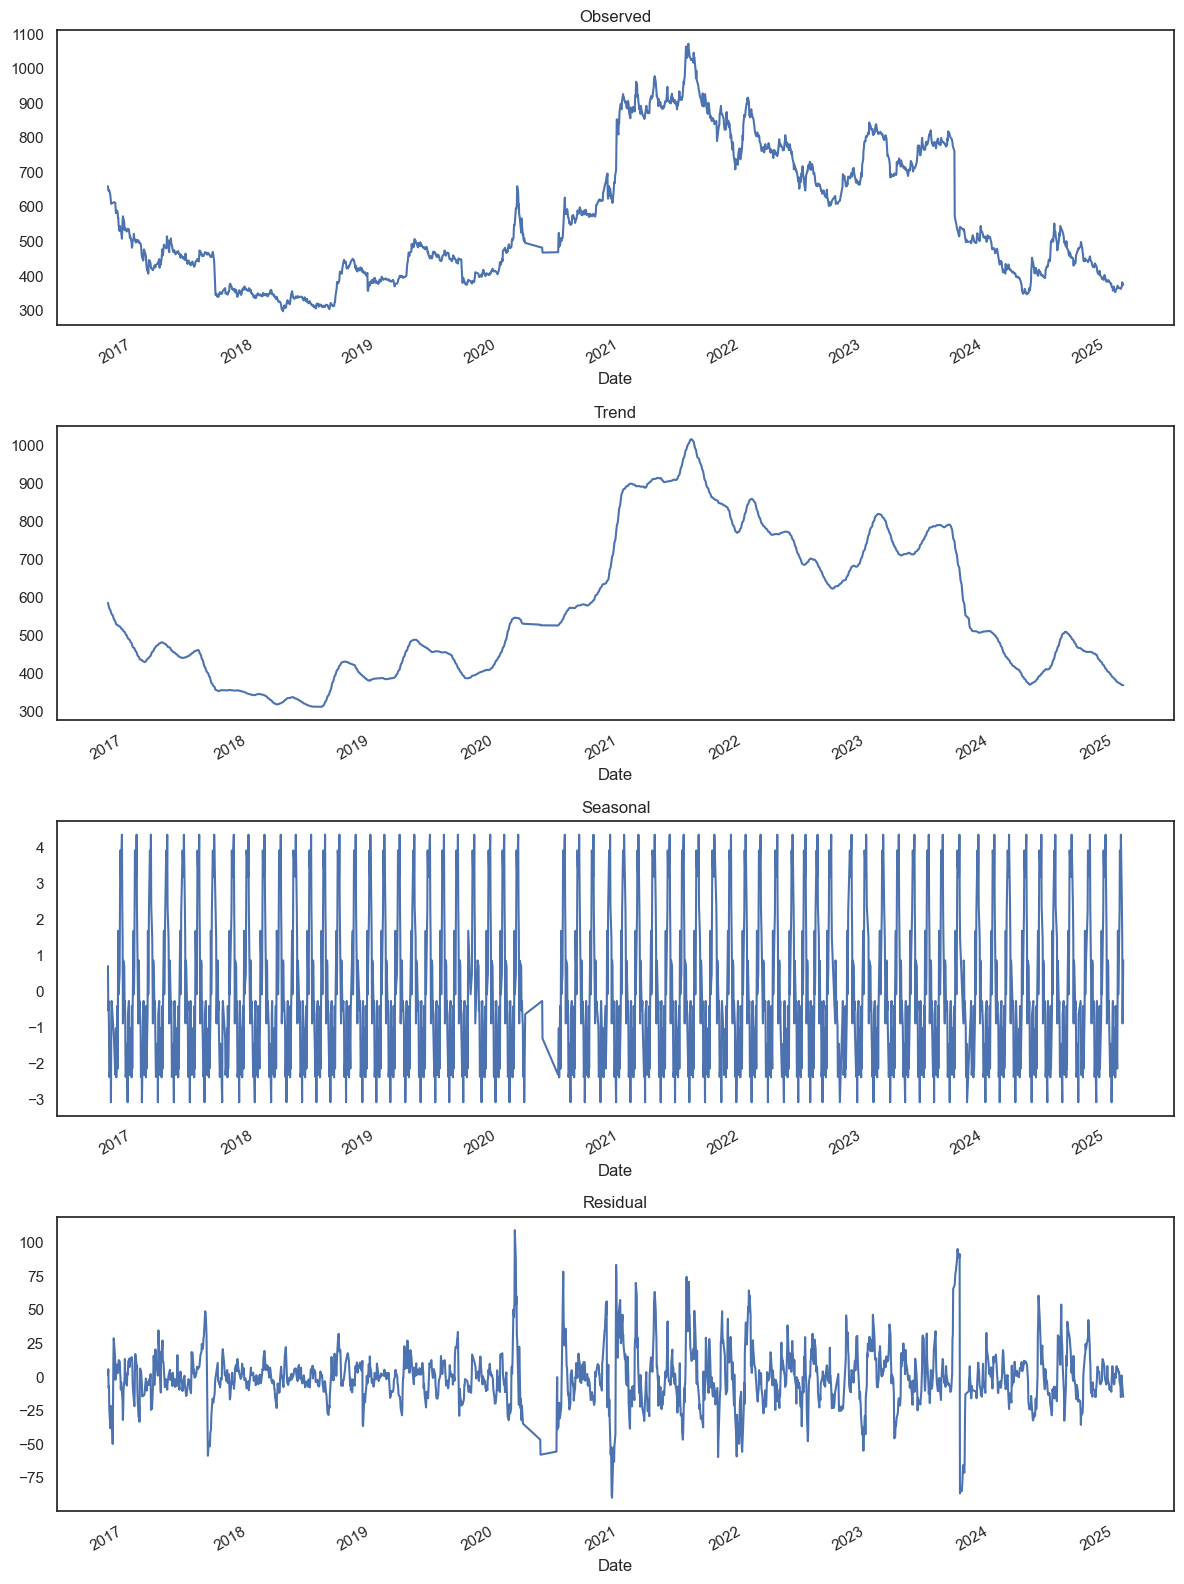

In [78]:
# Plot the decomposition
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 16))
result.observed.plot(ax=ax1)
ax1.set_title('Observed')
result.trend.plot(ax=ax2)
ax2.set_title('Trend')
result.seasonal.plot(ax=ax3)
ax3.set_title('Seasonal')
result.resid.plot(ax=ax4)
ax4.set_title('Residual')
plt.tight_layout()
plt.show()

In [79]:
# close_adbl = df['Close']
# result = seasonal_decompose(close_adbl, model='multiplicative', period=30)

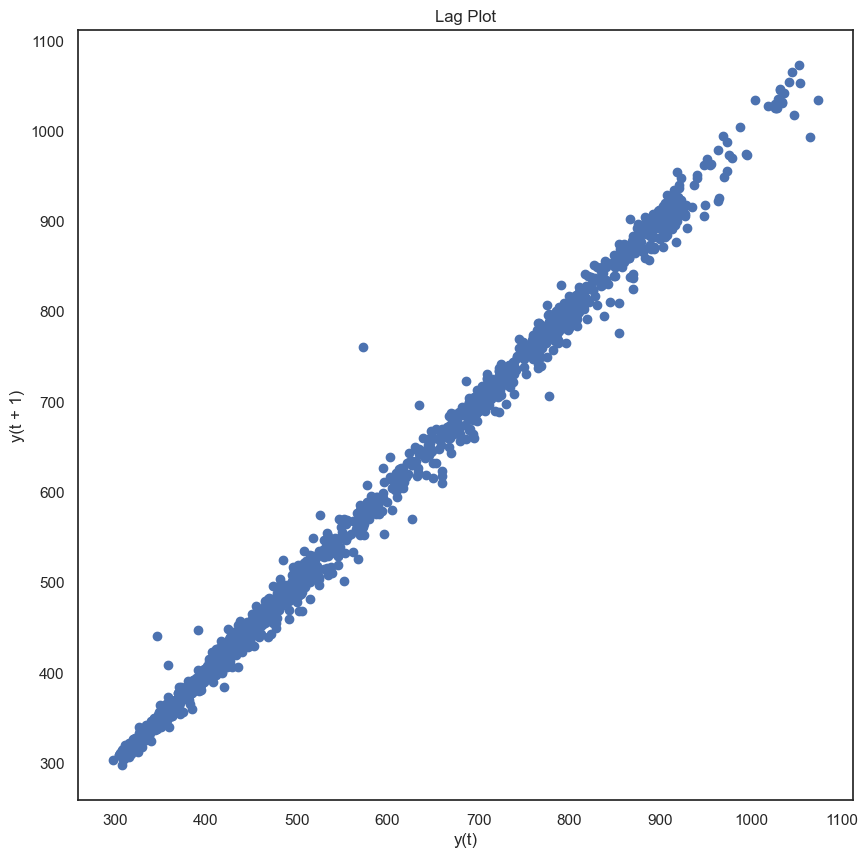

In [80]:
#lag plot
plt.figure(figsize=(10, 10))
lag_plot(close,lag=1) #check lag values at different steps to decide time-steps ie taking prev days values
plt.title('Lag Plot')
plt.show()

In [81]:
def test_stationarity(timeseries):
    result = adfuller(timeseries, autolag='AIC')
    print('ADF Statistic:', result[0])
    print('p-value:', result[1])
    print('Critical Values:', result[4])

test_stationarity(close)

ADF Statistic: -1.640656054127501
p-value: 0.4619180060010962
Critical Values: {'1%': np.float64(-3.433767579644038), '5%': np.float64(-2.8630496663460607), '10%': np.float64(-2.567573687930666)}


In [82]:
df['closediff'] = df['Close'].diff()


In [83]:
df.dropna()

,Date,Open,High,Low,Close,per_change,Qty,Turnover,EPS,PE,...,MACDSignal,MACDHist,BollingerUpper,BollingerMiddle,BollingerLower,ATR,UpperBand,LowerBand,Supertrend,closediff
199,2024-04-07,398.0,398.8,390.3,397.0,-0.25,80715,31781656.1,25.59,15.513873,...,-3.954676,6.595876,407.148185,367.49,327.831815,13.256943,434.320830,354.779170,0.000000,-1.8
200,2024-04-04,400.0,402.0,398.0,398.0,-1.00,61026,24350543.2,25.59,15.552950,...,-2.444897,6.039117,410.813387,369.89,328.966613,12.431249,437.293747,362.706253,0.000000,1.0
201,2024-04-03,410.0,410.0,399.0,402.0,-1.18,59686,23975302.8,25.59,15.709261,...,-1.032114,5.651132,414.618038,372.49,330.361962,12.388124,441.664372,367.335628,0.000000,4.0
202,2024-04-02,412.0,412.0,405.0,406.8,-0.27,28130,11430729.5,25.59,15.896835,...,0.324747,5.427442,418.507609,375.43,332.352391,12.149312,444.947935,372.052065,0.000000,4.8
203,2024-04-01,410.0,412.5,405.0,407.9,0.22,51254,20869305.3,25.59,15.939820,...,1.592237,5.069962,421.683454,378.48,335.276546,11.684380,443.803141,373.696859,0.000000,1.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1915,2016-10-20,648.0,651.0,643.0,648.0,0.00,3303,2133809.0,17.94,36.120401,...,21.614488,4.149486,655.485967,587.35,519.214033,21.312721,710.938163,583.061837,378.655328,13.0
1916,2016-10-19,646.0,651.0,642.0,648.0,0.00,6977,4505359.0,17.94,36.120401,...,22.645602,4.124455,661.328733,593.10,524.871267,20.081449,706.744347,586.255653,378.655328,0.0
1917,2016-10-18,651.0,655.0,644.0,646.0,0.00,6085,3939778.0,17.94,36.008919,...,23.535218,3.558465,665.768836,598.40,531.031164,19.173304,707.019912,591.980088,378.655328,-2.0
1918,2016-10-17,660.0,660.0,647.0,651.0,0.00,5758,3758521.0,17.94,36.287625,...,24.315642,3.121694,670.102108,603.70,537.297892,18.655974,709.467921,597.532079,378.655328,5.0


* Conclusion: Since the ADF statistic is not less than the critical values and the p-value is greater than 0.05, we conclude that the time series is non-stationary.

In [84]:
# def test_stationarity(timeseries):
#     result = adfuller(timeseries, autolag='AIC')
#     print('ADF Statistic:', result[0])
#     print('p-value:', result[1])
#     print('Critical Values:', result[4])

# test_stationarity(closediff)

In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1920 entries, 0 to 1919
Data columns (total 27 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             1920 non-null   datetime64[ns]
 1   Open             1920 non-null   float64       
 2   High             1920 non-null   float64       
 3   Low              1920 non-null   float64       
 4   Close            1920 non-null   float64       
 5   per_change       1920 non-null   float64       
 6   Qty              1920 non-null   int64         
 7   Turnover         1920 non-null   float64       
 8   EPS              1920 non-null   float64       
 9   PE               1920 non-null   float64       
 10  EMA5             1916 non-null   float64       
 11  EMA50            1871 non-null   float64       
 12  EMA200           1721 non-null   float64       
 13  RSI9             1911 non-null   float64       
 14  RSI14            1906 non-null   float64

In [86]:
# correlation_matrix = df.corr()
# plt.figure(figsize=(10, 8))
# sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
# plt.show()

df3.sort_values(by=["Date"], inplace=True, ascending=True)
df3.head(20)

,Open,High,Low,Close,Qty,Turnover,EPS,PE,RSI9,RSI14,RSI25,MACD,MACDSignal,BollingerUpper,BollingerMiddle,BollingerLower,ATR
Date,,,,,,,,,,,,,,,,,
2016-10-16,678.0,666.0,658.0,660.0,3547,2347771.0,17.94,36.789298,84.089037,78.156925,71.761055,28.111853,25.074884,671.745430,610.20,548.654570,18.290376
2016-10-17,660.0,660.0,647.0,651.0,5758,3758521.0,17.94,36.287625,81.573967,76.245316,70.497642,27.437336,24.315642,670.102108,603.70,537.297892,18.655974
2016-10-18,651.0,655.0,644.0,646.0,6085,3939778.0,17.94,36.008919,80.013847,75.122158,69.776467,27.093683,23.535218,665.768836,598.40,531.031164,19.173304
2016-10-19,646.0,651.0,642.0,648.0,6977,4505359.0,17.94,36.120401,82.497402,76.465014,70.437647,26.770058,22.645602,661.328733,593.10,524.871267,20.081449
2016-10-20,648.0,651.0,643.0,648.0,3303,2133809.0,17.94,36.120401,82.497402,76.465014,70.437647,25.763975,21.614488,655.485967,587.35,519.214033,21.312721
2016-10-23,648.0,650.0,633.0,635.0,6063,3890654.0,17.94,35.395764,79.178186,73.844620,68.658609,24.105099,20.577117,647.481760,581.70,515.918240,21.903023
2016-10-24,635.0,636.0,624.0,627.0,6771,4260641.0,17.94,34.949833,76.768228,72.067466,67.503286,22.960786,19.695121,643.790558,575.35,506.909442,21.781137
2016-10-25,627.0,626.0,610.0,615.0,10593,6519013.0,17.94,34.280936,72.528801,69.147625,65.681594,21.980797,18.878705,637.078008,570.70,504.321992,21.867930
2016-10-26,615.0,615.0,600.0,609.0,19957,12096246.0,17.94,33.946488,70.104125,67.573900,64.732630,21.632073,18.103182,631.300217,568.05,504.799783,22.408811


In [87]:
from datetime import datetime

df3['year'] = df3.Date.dt.year
df3['month'] = df3.Date.dt.month
df3['day'] = df3.Date.dt.day
df3['dayofweek'] = df3.Date.dt.dayofweek

#Set Date column as the index column.
df3.set_index('Date', inplace=True)
df3.head(20)
#  0 is the starting of the week, i.e., 0 is Monday and 6 is Sunday.

AttributeError: 'DataFrame' object has no attribute 'Date'

In [ ]:
df3[df3['dayofweek'] == 4].tail(50)

,Open,High,Low,Close,per_change,Qty,Turnover,EPS,PE,EMA5,...,BollingerLower,ATR,UpperBand,LowerBand,Supertrend,closediff,year,month,day,dayofweek
Date,,,,,,,,,,,,,,,,,,,,,
2022-09-16,621.0,629.9,618.0,627.0,-0.48,19072,11919312.7,39.13,16.023511,616.646454,...,592.412192,17.286960,675.810879,572.089121,650.736526,9.9,2022,9,16,4
2022-09-02,649.9,650.0,642.0,645.0,0.55,4993,3227492.8,39.13,16.483516,643.162793,...,597.191724,14.468883,689.406649,602.593351,650.736526,-3.0,2022,9,2,4
2022-08-26,657.0,660.0,652.0,655.0,-0.61,18693,12237204.0,39.13,16.739075,648.443921,...,612.452786,13.491833,696.475498,615.524502,650.736526,8.9,2022,8,26,4
2022-08-05,700.0,704.8,695.0,695.5,-1.49,33014,23041620.0,39.13,17.774086,689.785908,...,637.049843,15.049014,745.047043,654.752957,650.736526,-3.5,2022,8,5,4
2022-07-29,712.0,715.0,706.0,707.9,-0.16,30305,21491560.1,39.13,18.090979,713.797528,...,640.592582,16.632349,760.397046,660.602954,650.736526,-17.1,2022,7,29,4
2022-07-22,724.0,724.9,712.0,713.0,-1.25,47223,33795047.5,39.13,18.221314,717.478795,...,661.185179,17.914506,772.193519,664.706481,650.736526,-11.0,2022,7,22,4
2022-07-15,694.0,704.0,688.0,696.0,0.29,44293,30796694.2,41.24,16.876819,704.615422,...,692.540095,17.444821,748.334463,643.665537,650.736526,-7.0,2022,7,15,4
2022-07-08,685.0,687.0,664.3,668.0,-2.48,45733,30725228.8,41.24,16.197866,669.644829,...,657.914513,23.646519,746.589558,604.710442,650.736526,20.0,2022,7,8,4
2022-07-01,701.0,705.0,687.0,689.9,-1.26,65273,45132655.0,41.24,16.728904,696.190630,...,653.852989,27.982636,779.947908,612.052092,650.736526,-28.1,2022,7,1,4


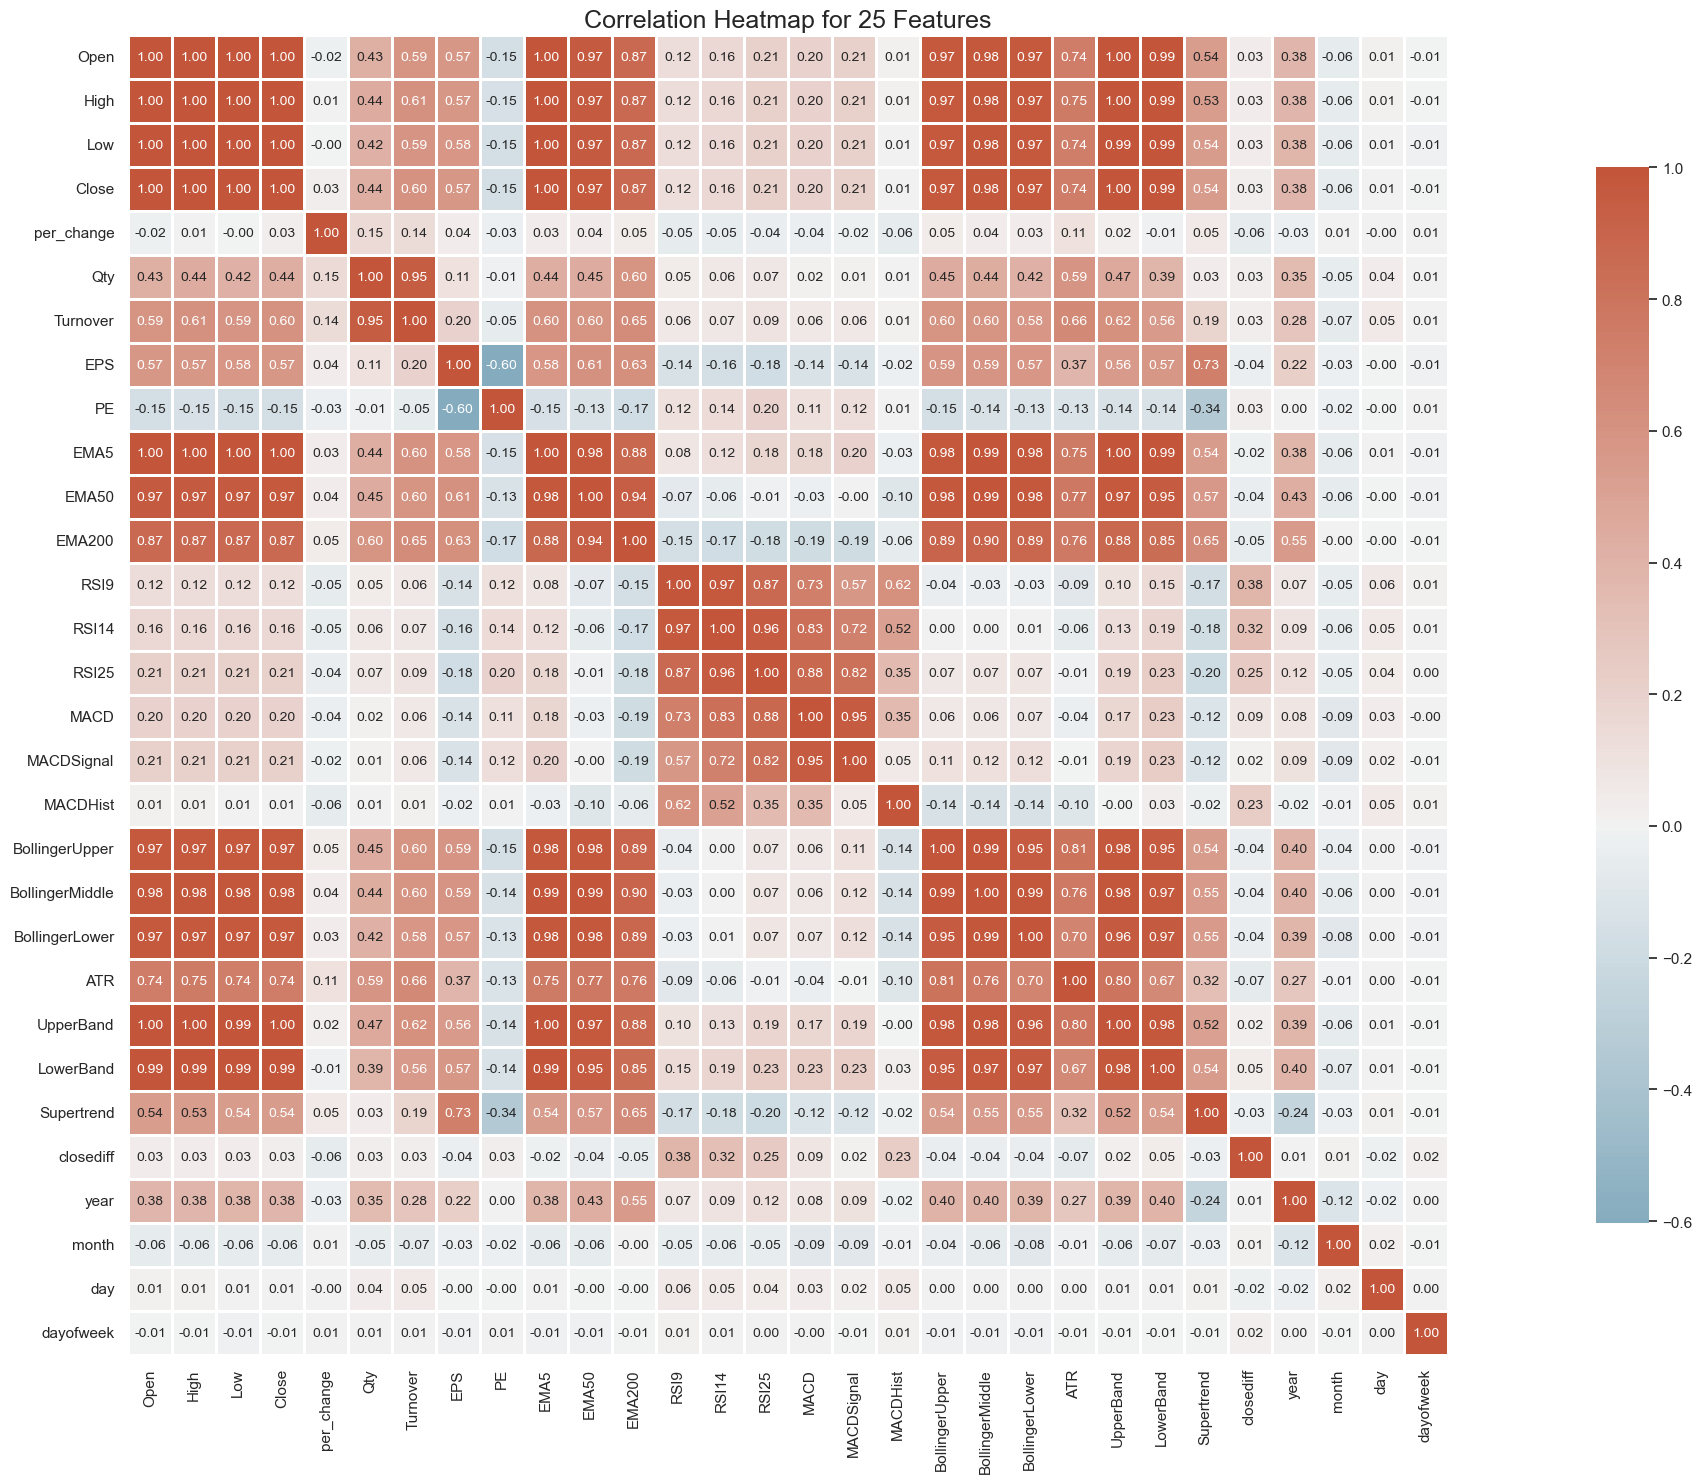

In [ ]:
# Step 1: Calculate the correlation matrix
corr_matrix = df3.corr()

# Step 2: Plot the heatmap using Seaborn
plt.figure(figsize=(30, 15))  # Adjust size as per your dataset

# Create a custom diverging color palette
sns.set(style="white")  # Set style for better presentation
cmap = sns.diverging_palette(230, 20, as_cmap=True)  # Diverging color map

# Create heatmap with annotation and color intensity
sns.heatmap(corr_matrix, 
            annot=True,             # Annotate the values
            cmap=cmap,              # Use diverging palette for better clarity
            center=0,               # Center the colors around 0
            square=True,            # Square-shaped grid
            linewidths=0.8,         # Line width between cells
            fmt=".2f",              # Formatting for correlation values
            cbar_kws={"shrink": 0.8},  # Adjust color bar size
            annot_kws={"size": 10})    # Font size of annotations

# Step 3: Title and display the plot
plt.title('Correlation Heatmap for 25 Features', fontsize=18)
plt.tight_layout()  # Make sure everything fits
plt.show()

<Axes: xlabel='year'>

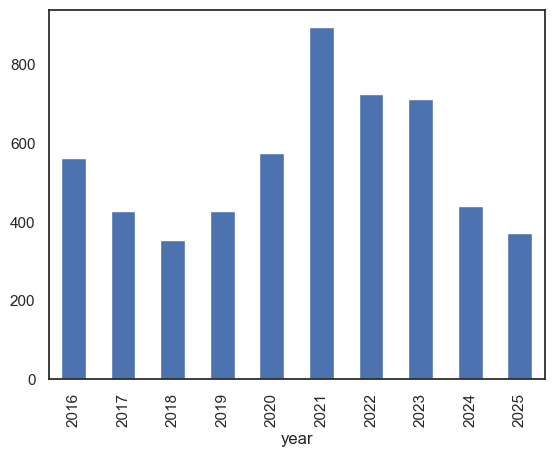

In [ ]:
# Yearly VWAP of Maruti Stocks

df3.groupby('year')['Close'].mean().plot.bar()

<Axes: xlabel='month'>

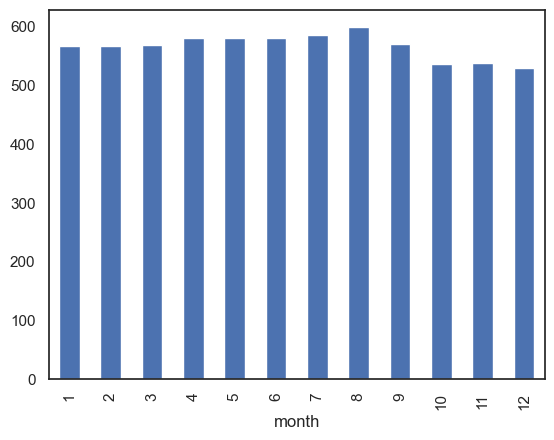

In [ ]:
df3.groupby('month')['Close'].mean().plot.bar()

<Axes: xlabel='day'>

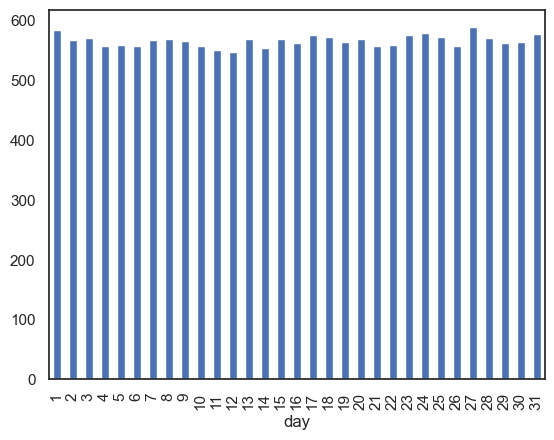

In [ ]:
df3.groupby('day')['Close'].mean().plot.bar()

<Axes: xlabel='dayofweek'>

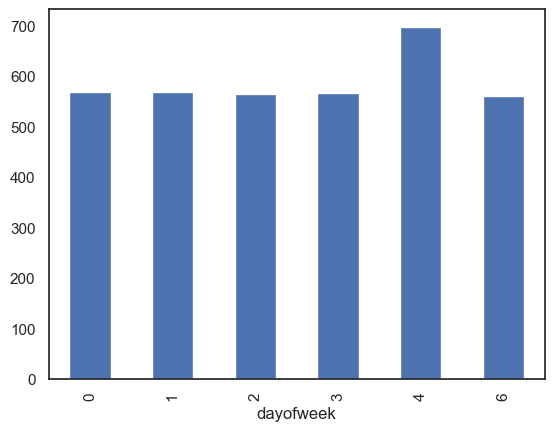

In [ ]:
df3.groupby('dayofweek')['Close'].mean().plot.bar()

In [ ]:
#cross-corelational matrix:
from statsmodels.tsa.stattools import ccf
x = df['Close'].values
y = df['Volume'].values
cross_corr = ccf(x, y)
plt.plot(cross_corr)
plt.title('Cross-Correlation Function')
plt.show()


KeyError: 'Volume'

In [ ]:
#plot of Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(close, ax=ax1, lags=100)
plot_pacf(close, ax=ax2, lags=100)
plt.tight_layout()
plt.show()

#SARIMA

In [ ]:
from sklearn.model_selection import train_test_split as split
from sklearn.model_selection import TimeSeriesSplit
from statsmodels.tsa.statespace.sarimax import SARIMAX
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, mean_absolute_error
import itertools

In [ ]:
# Resample the data to the monthly level
monthly_mean_df = df.resample('ME').mean()

In [ ]:
#TRAIN TEST SPLIT
modelling_series_adbl = monthly_mean_df['Close']
train,test = split(modelling_series_adbl,train_size=0.8,shuffle=False)

In [ ]:
#Hyperparameters Tuning
# Define the p, d, q ranges
p = d = q = range(0, 3)
pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], 12) for x in list(itertools.product(p, d, q))]

# Initialize lists to store the parameters and AIC values
list_param = []
list_param_seasonal = []
list_results_aic = []

# Initialize variables to track the best model
best_aic = float("inf")
best_param = None
best_param_seasonal = None

# Loop through all combinations of pdq and seasonal_pdq
for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            # Fit the SARIMA model
            model = SARIMAX(train,
                            order=param,
                            seasonal_order=param_seasonal,
                            enforce_stationarity=False,
                            enforce_invertibility=False)

            results = model.fit()

            # Append parameters and AIC to the lists
            list_param.append(param)
            list_param_seasonal.append(param_seasonal)
            list_results_aic.append(results.aic)
            
            print('ARIMA{}x{}12 - AIC:{}'.format(param, param_seasonal, results.aic))

            # Check if this model has the lowest AIC
            if results.aic < best_aic:
                best_aic = results.aic
                best_param = param
                best_param_seasonal = param_seasonal

        except:
            continue

# Print the best model parameters
print("\nBest Model:")
print('ARIMA{}x{}12 - AIC:{}'.format(best_param, best_param_seasonal, best_aic))


In [ ]:
#Train Test Data with Predictions
model = sm.tsa.SARIMAX(modelling_series_adbl,order=(1,1,2),seasonal_order=(1,0,1,12))
results=model.fit()
forecasts_train = results.predict(start='2022-01-31',end='2023-08-31')
forecasts_test = results.predict(start='2023-09-30',end='2024-09-30')

sd='2022-01-31'
ed='2023-08-31'
sd2='2023-09-30'
ed2='2024-09-30'

fig,(ax1,ax2) = plt.subplots(2,figsize=(18,10))

forecasts_train.plot(label='Forecasts',ax=ax1,title='SARIMA Forecasting - Train Data')
modelling_series_adbl.loc[sd:ed].plot(label='Actual',ax=ax1)
ax1.set_ylabel('Stock Price')

forecasts_test.plot(label='Forecasts',ax=ax2,title='SARIMA Forecasting - Test Data')
modelling_series_adbl.loc[sd2:ed2].plot(label='Actual',ax=ax2)
ax2.set_ylabel('Stock Price')

ax1.legend()
ax2.legend()
plt.tight_layout(pad=2)

In [ ]:

#Train Test Data with Predictions and Forecast

# Fit the model as before
model = sm.tsa.SARIMAX(modelling_series_adbl, order=(1, 1, 2), seasonal_order=(1, 0, 1, 12))
results = model.fit()

# Train and Test Forecasts
forecasts_train = results.predict(start='2022-02-28', end='2023-08-31')
forecasts_test = results.predict(start='2023-09-30', end='2024-09-30')

# Forecast for the next 10 months after the test data
next_10_months_forecast = results.get_forecast(steps=10)
forecast_index = pd.date_range(start='2024-10-31', periods=10, freq='M')  # Correct frequency (monthly)

# Combine the forecasts for plotting
forecast_combined = pd.concat([
    forecasts_train,
    forecasts_test,
    pd.Series(next_10_months_forecast.predicted_mean, index=forecast_index)
])
# Start plotting
fig, ax = plt.subplots(figsize=(18, 8))

# Plot Actual Data
modelling_series_adbl.plot(ax=ax, label='Actual', color='blue', linewidth=2.5)  # Bold actual data

# Plot Train Forecast Data
forecasts_train.plot(ax=ax, label='Forecast - Train', color='orange', linestyle='--', linewidth=2.5)  # Bolder forecast

# Plot Test Forecast Data
forecasts_test.plot(ax=ax, label='Forecast - Test', color='green', linestyle='--', linewidth=2.5)

# Plot Next 10 Months Forecast Data
next_10_months_forecast.predicted_mean.plot(ax=ax, label='Next 10 Months Forecast', color='purple', linestyle='--', linewidth=2.5)
# Set graph limits
y_min = min(modelling_series_adbl.min(), forecasts_train.min(), forecasts_test.min(), next_10_months_forecast.predicted_mean.min())
y_max = max(modelling_series_adbl.max(), forecasts_train.max(), forecasts_test.max(), next_10_months_forecast.predicted_mean.max())
ax.set_ylim(y_min - 10, y_max + 10)  # Setting limits for the y-axis

# Customize labels and title
ax.set_xlabel('Date')
ax.set_ylabel('Stock Price')
ax.set_title('SARIMA Forecasting - Train, Test, and Next 10 Months')

# Display the legend
ax.legend()

# Show the plot
plt.tight_layout()
plt.show()


In [ ]:
#SARIMA Evaluation Metrics
# Initialize lists to store metrics for each split
mae_list = []
mse_list = []
rmse_list = []
mape_list = []

## Using TimeSeriesSplit from sklearn library
time_series_splits = TimeSeriesSplit(n_splits=4)
X = modelling_series_adbl.values

# Assume time_series_splits and X are already defined, and you're using SARIMAX
for train_index, test_index in time_series_splits.split(X):
    train = X[train_index]
    test = X[test_index]

    # Fit the model on the training data
    model = SARIMAX(train, order=(2, 1, 2), seasonal_order=(0, 1, 2, 12))
    results = model.fit()

    # Forecast on the test data
    forecasts = results.predict(start=len(train), end=len(train) + len(test) - 1)

    # Calculate evaluation metrics
    mae = mean_absolute_error(test, forecasts)
    mse = mean_squared_error(test, forecasts)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((test - forecasts) / test)) * 100

    # Append metrics to their respective lists
    mae_list.append(mae)
    mse_list.append(mse)
    rmse_list.append(rmse)
    mape_list.append(mape)

    # Print evaluation metrics for this split
    print(f'MAE for this split: {mae}')
    print(f'MSE for this split: {mse}')
    print(f'RMSE for this split: {rmse}')
    print(f'MAPE for this split: {mape:.2f}%')

# Calculate and print average values across all splits
average_mae = np.mean(mae_list)
average_mse = np.mean(mse_list)
average_rmse = np.mean(rmse_list)
average_mape = np.mean(mape_list)

print(f'\nAverage MAE: {average_mae}')
print(f'Average MSE: {average_mse}')
print(f'Average RMSE: {average_rmse}')
print(f'Average MAPE: {average_mape:.2f}%')

In [ ]:
forecasts 
